In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from sklearn.decomposition import PCA
from itertools import combinations
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr, pearsonr
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy.spatial.distance import pdist, squareform
from pathlib import Path
import prince
import dash
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import prince
from sklearn.model_selection import LeaveOneOut
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.linear_model import ElasticNet
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster
from matplotlib.patches import Ellipse
from difflib import get_close_matches
from sklearn.impute import KNNImputer
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from scipy.cluster.hierarchy import linkage, dendrogram
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
from sklearn.neighbors import NearestNeighbors



# Data Aggregation: Combining Sample and Control Compound Files

In [2]:
from compound_analysis_module import combine_compound_data

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\ALVERSTONE R..csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\ANTI.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\AVARNA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\CAMEL.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\CHOPIN.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\FELSINA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\INNOVATOR.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\JAERLA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\SARPO MIRA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\VAN GOGH.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\ALTUS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\ARDECHE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\EL MUNDO.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\FABULA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\FONTANE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\JENNIFER.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\RED SCARLETT.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\RUSSET BURBANK.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\SUNDANCE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\ALTURAS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\BARAKA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\ESCORT.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\FRISIA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\MARILYN.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\ORIANA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\SAGITTA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\SUPERIOR.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\NICOLA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\ALTHEA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\ANIVIA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\DONALD.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\FARIDA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\HANSA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\KENNEBEC.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\MEMPHIS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\BILDTSTAR.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\REDDALE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\VIOLET QUEEN.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\ADORA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\DESIREE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\CLEARWATER R.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\PAYETTE RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\PRINCEOFORANGE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\SYMFONIA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\VE 71-105.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\ARIZONA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\DIAMANT.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\AVENGER.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\CARRERA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\EVEREST.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\EVORA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\FENWAY RED.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\LADY CLAIRE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\RANGER RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\RICKEY RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\FORTUS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\AGRIA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\CAROLINA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\COLOMBA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\CRISPS4ALL.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\DEODARA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\TETON RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\KONDOR.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\MUSE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\PARELLA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\ROYAL.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\CARDYMA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\CECILE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\FLAMENCO.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\HERMES.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\NADINE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\NOBLESSE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\IVORY RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\SABABA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\SALINERO.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\SPUNTA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\ALOUETTE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\ATLANTIC.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\BERBER.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\BLUE STAR.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\CARLITA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\CHALLENGER.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\CIKLAMEN.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\MONALISA.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\PEE WEE RUSSET.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\ARGOS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\BINTJE.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\DELIA RED.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\FESTIEN.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\MULBERRYBEAUTY.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\OSPREY.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\SMART.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\TAURUS.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\TRIPLE7.csv",

]
#we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\qc.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\env.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\blank.csv")


base_compound_dir = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds"

# Output file where combined data will be saved
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\combined.csv"

# ---------------------------------------------------------------
# Automatically detect QC, ENV, and BLANK files from all folders
# ---------------------------------------------------------------
qc_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*qc*.csv"))
env_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*env*.csv"))
blank_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*blank*.csv"))

print(f"Samples listed manually: {len(sample_files)}")
print(f"QC files found: {len(qc_files)}")
print(f"Env files found: {len(env_files)}")
print(f"Blank files found: {len(blank_files)}")
import os

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

compound_df = combine_compound_data(
    sample_files=sample_files,
    base_dir=base_compound_dir,
    output_path=output_path,
    qc_files=qc_files,
    env_files=env_files,
    blank_files=blank_files
)
compound_df["FileType"].value_counts()



Samples listed manually: 94
QC files found: 19
Env files found: 10
Blank files found: 10

Combined file saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\combined.csv

FileType counts:
FileType
sample    2369
qc        1083
env        647
blank      587
Name: count, dtype: int64

Preview of combined data:
   Component RT            Compound Name  Match Factor  Best Hit Formula  \
0      2.185667  2-Propanone, 1-methoxy-     91.035716      True  C4H8O2   
1      2.899483       Butanal, 3-methyl-     95.554383      True  C5H10O   
2      3.317483                 Pentanal     91.360114      True  C5H10O   
3      4.069867      Disulfide, dimethyl     94.565354      True  C2H6S2   
4      5.282067                  Hexanal     93.609765      True  C6H12O   

  FileType           FileName  
0   sample  ALVERSTONE R..csv  
1   sample  ALVERSTONE R..csv  
2   sample  ALVERSTONE R..csv  
3   sample  ALVERSTONE R..csv  
4   sample  ALVERSTONE R..csv  


FileType
sample    2369
qc        1083
env        647
blank      587
Name: count, dtype: int64

# contamination filtering

In [3]:
from compound_analysis_module import filter_real_compounds
real_compounds = filter_real_compounds(compound_df, rt_tolerance=0.5)
real_compounds.shape

Sample compounds before filtering: 2369
Sample compounds after filtering: 822
Removed 1547 sample peaks (ΔRT ≤ 0.5)


(822, 7)

# Matching NIST-Identified Compounds with GC–MS Peak Intensities

In [4]:
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import match_compounds_to_peaks


compound_intensity_df, unmatched_df = match_compounds_to_peaks(
    compound_df=compound_df,
    samples_filtered_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\biorep1\samples_filtered.csv",
    output_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\compound_intensity_matched.csv",
    rt_tolerance=0.5
)



Samples kept after filtering: 186 unique

Unique varieties matched: 94

Matched compound intensity file saved to:
C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\compound_intensity_matched.csv

Varieties missing in samples_filtered: {'blank', 'env', 'qcb', 'qc'}


# Checking the presence of known potato aroma compounds

In [5]:
from difflib import get_close_matches
import pandas as pd
import importlib
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import extract_aroma_compounds

# --- 1. Known potato aroma compounds (from literature) ---

potato_aromas = [

    # --- Aldehydes (green, fatty, grassy) ---
    "Hexanal", "Heptanal", "Octanal", "Nonanal", "Decanal",
    "Pentanal", "2-Methylbutanal", "3-Methylbutanal",  # also known as isovaleraldehyde
    "Butanal, 3-methyl-", "Propanal", "4-Heptenal", "2,4-Decadienal",
    "2-Trans-nonenal", "2-Trans-octenal",

    # --- Alcohols (earthy, mushroom-like, floral) ---
    "1-Heptanol", "1-Nonanol", "1-Octen-3-ol", "1-Phenylethanol",
    "Hexanol", "2-Methyl-1-propanol", "3-Methyl-1-butanol", "Ethanol",

    # --- Ketones (buttery, creamy, fruity) ---
    "2-Heptanone", "2-Nonanone", "3-Heptanone", "3-Octanone",
    "2,3-Butanedione", "2,3-Pentanedione", "Acetophenone",
    "2-Propanone, 1-methoxy-", "4-Methyl-2-pentanone",

    # --- Sulfur compounds (cooked, savory, meaty, boiled potato-like) ---
    "Methanethiol", "Methional", "Dimethyl disulfide", "Dimethyl trisulfide",
    "Dimethyl tetrasulfide", "Carbon disulfide", "Hydrogen sulfide",
    "2-Methyl-3-furanthiol", "3-Methylthiopropanal", "2-Acetylthiazole",
    "2-Methyl-3-thiazoline", "2-Methylthiazole", "3-(Methylthio)propanal",
    "Allyl methyl sulfide",

    # --- Acids (fatty, sour, rancid) ---
    "Acetic acid", "Butanoic acid", "Hexanoic acid", "Isobutyric acid",
    "Octanoic acid", "Propanoic acid", "Isovaleric acid",

    # --- Esters (fruity, sweet, green) ---
    "Ethyl acetate", "Isoamyl acetate", "Ethyl butanoate",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "Ethyl propanoate", "Methyl propanoate", "Ethyl pentanoate",

    # --- Pyrazines (roasted, nutty, earthy) ---
    "2-Acetylpyrazine", "2-Ethyl-3,5-dimethylpyrazine",
    "2-Isobutyl-3-methoxypyrazine", "2-Isopropyl-3-methoxypyrazine",
    "2-Ethyl-3-methylpyrazine", "Trimethylpyrazine", "Tetramethylpyrazine",
    "2,5-Dimethylpyrazine", "2,6-Dimethylpyrazine", "2-Methylpyrazine",

    # --- Aromatics & furans (sweet, caramel, floral) ---
    "Benzaldehyde", "Phenylacetaldehyde", "Furfural", "5-Methylfurfural",
    "Benzeneacetaldehyde", "Benzyl alcohol", "Phenylethyl alcohol"
]





aroma_output_path = (
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\aroma_compound_intensity.csv"
)

aroma_sample_df = extract_aroma_compounds(
    compound_intensity_df=compound_intensity_df,
    potato_aromas=potato_aromas,
    output_path=aroma_output_path
)



Number of aroma compound records: 1358
Number of unique samples: 94
Number of unique varieties: 94

Variety counts:
Variety
INNOVATOR         68
LADY CLAIRE       61
ALTUS             34
IVORY RUSSET      21
DONALD            20
                  ..
BINTJE             6
MULBERRYBEAUTY     5
DELIA RED          5
TAURUS             5
ARGOS              4
Name: count, Length: 94, dtype: int64

Saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\aroma_compound_intensity.csv


# Adding Sensory Descriptions to Identified Aroma Compounds

In [6]:
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import  add_aroma_descriptions

aroma_descriptions = {
    # --- Aldehydes (green, fatty, grassy) ---
    "Propanal": "Sharp, pungent, green",
    "Butanal, 3-methyl-": "Malty, chocolate, cocoa-like (Maillard reaction product)",
    "Pentanal": "Fatty, green, pungent",
    "2-Methylbutanal": "Malty, chocolate, roasted (amino acid-derived)",
    "3-Methylbutanal": "Malty, chocolate, roasted (Leu-derived Strecker aldehyde)",
    "Hexanal": "Green, grassy, fresh-cut potato",
    "Heptanal": "Fatty, citrus-like, slightly green",
    "Octanal": "Citrus, fruity, green",
    "Nonanal": "Waxy, citrus, floral (lipid oxidation product)",
    "Decanal": "Citrus, fatty, waxy, potato-like",
    "2-Trans-nonenal": "Cardboard, fatty, old potato note",
    "2-Trans-octenal": "Green, fatty, cucumber-like",
    "4-Heptenal": "Fatty, oily, green",
    "2,4-Decadienal": "Fatty, fried, potato-chip-like",
    "Phenylacetaldehyde": "Honey-like, floral, sweet potato note",
    "Benzaldehyde": "Almond, cherry, sweet",

    # --- Alcohols (earthy, mushroom-like, floral) ---
    "1-Heptanol": "Floral, herbal, fatty",
    "1-Nonanol": "Waxy, floral, oily",
    "1-Octen-3-ol": "Mushroom, earthy, raw potato",
    "1-Phenylethanol": "Floral, rose, sweet",
    "Hexanol": "Green, grassy, herbaceous",
    "2-Methyl-1-propanol": "Fusel, solvent-like",
    "3-Methyl-1-butanol": "Whiskey-like, malty, fusel",
    "Ethanol": "Alcoholic, sweet",

    # --- Ketones (buttery, creamy, fruity) ---
    "2-Heptanone": "Fruity, blue cheese, creamy",
    "2-Nonanone": "Fatty, floral, soapy",
    "3-Heptanone": "Cheesy, earthy, fruity",
    "3-Octanone": "Mushroom, earthy, fatty",
    "2,3-Butanedione": "Buttery, creamy, cooked potato",
    "2,3-Pentanedione": "Creamy, buttery, sweet",
    "Acetophenone": "Floral, sweet, almond-like",
    "2-Propanone, 1-methoxy-": "Solvent, ether-like",
    "4-Methyl-2-pentanone": "Solvent, fruity, pungent",
    "2-Undecanone": "Fatty, waxy, green (potato tuber-like note)",

    # --- Sulfur compounds (cooked, savory, meaty, boiled potato-like) ---
    "Methanethiol": "Sulfurous, cabbage, cooked potato",
    "Methional": "Cooked potato, meaty, sulfurous (key potato note)",
    "Dimethyl disulfide": "Garlic, onion, sulfurous",
    "Dimethyl trisulfide": "Cabbage, onion, sulfurous",
    "Dimethyl tetrasulfide": "Strongly sulfurous, boiled vegetable",
    "Carbon disulfide": "Sulfurous, chemical",
    "Hydrogen sulfide": "Rotten egg, sulfurous",
    "2-Methyl-3-furanthiol": "Meaty, roasted, savory",
    "3-Methylthiopropanal": "Cooked potato, malty, onion-like",
    "2-Acetylthiazole": "Roasted, popcorn-like",
    "2-Methylthiazole": "Nutty, roasted",
    "2-Methyl-3-thiazoline": "Meaty, roasted",
    "3-(Methylthio)propanal": "Boiled potato, onion-like",
    "Allyl methyl sulfide": "Garlic, onion-like",

    # --- Acids (fatty, sour, rancid) ---
    "Acetic acid": "Vinegar-like, sour",
    "Butanoic acid": "Rancid, cheesy, sweaty",
    "Hexanoic acid": "Fatty, sweaty, rancid",
    "Isobutyric acid": "Cheesy, rancid, sour",
    "Isovaleric acid": "Sweaty, cheesy, foot-like",
    "Octanoic acid": "Fatty, soapy, rancid",
    "Propanoic acid": "Sour, pungent",

    # --- Esters (fruity, sweet, green) ---
    "Ethyl acetate": "Fruity, solvent-like",
    "Isoamyl acetate": "Banana, fruity, sweet",
    "Ethyl butanoate": "Pineapple, fruity, sweet",
    "Ethyl hexanoate": "Apple, pineapple, sweet",
    "Methyl butanoate": "Apple, fruity, sweet",
    "Ethyl 2-methylbutanoate": "Apple, sweet, fruity",
    "Ethyl propanoate": "Fruity, rum-like",
    "Methyl propanoate": "Fruity, sweet",
    "Ethyl pentanoate": "Fruity, sweet",

    # --- Pyrazines (roasted, nutty, earthy) ---
    "2-Acetylpyrazine": "Nutty, roasted, popcorn-like",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, earthy, roasted",
    "2-Isobutyl-3-methoxypyrazine": "Green bell pepper, earthy",
    "2-Isopropyl-3-methoxypyrazine": "Green, earthy, potato peel-like",
    "2-Ethyl-3-methylpyrazine": "Nutty, roasted, earthy",
    "Trimethylpyrazine": "Roasted, cocoa, nutty",
    "Tetramethylpyrazine": "Roasted, nutty, cocoa",
    "2,5-Dimethylpyrazine": "Roasted, nutty",
    "2,6-Dimethylpyrazine": "Roasted, earthy",
    "2-Methylpyrazine": "Roasted, nutty, chocolate-like",

    # --- Aromatics & Furans (sweet, caramel, floral) ---
    "Benzeneacetaldehyde": "Honey, floral, sweet",
    "Benzyl alcohol": "Floral, sweet, mild",
    "Phenylethyl alcohol": "Rose-like, floral, sweet",
    "Furfural": "Sweet, almond, caramel",
    "5-Methylfurfural": "Caramel, baked, sweet"
}

# Run the function
aroma_sample_df = add_aroma_descriptions(
    aroma_sample_df=aroma_sample_df,
    aroma_descriptions=aroma_descriptions
)

# Save with descriptions
aroma_sample_df.to_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\aroma_compound_with_descriptions.csv",
    index=False
)



 All compounds have descriptions!
Number of unique aroma compounds: 47


# Creating the Aroma Compound Intensity Matrix

In [7]:
import compound_analysis_module
importlib.reload(compound_analysis_module)

from compound_analysis_module import create_aroma_intensity_matrix

aroma_matrix = create_aroma_intensity_matrix(aroma_sample_df)

# Optionally save for downstream PCA or clustering
aroma_matrix.to_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\aroma_intensity_matrix.csv",
    index=False
)



Aroma matrix created with shape: (94, 48)

Preview:
    Variety    1-Heptanol  1-Nonanol  1-Octen-3-ol  1-Phenylethanol  \
0     ADORA           NaN        NaN           NaN              NaN   
1     AGRIA           NaN        NaN           NaN              NaN   
2  ALOUETTE           NaN        NaN           NaN              NaN   
3    ALTHEA           NaN        NaN           NaN              NaN   
4   ALTURAS  84377.864228        NaN           NaN              NaN   

   2,3-Pentanedione  2,4-Decadienal  2,6-Dimethylpyrazine  \
0               NaN             NaN                   NaN   
1               NaN             NaN                   NaN   
2               NaN             NaN                   NaN   
3               NaN             NaN                   NaN   
4               NaN             NaN                   NaN   

   2-Isopropyl-3-methoxypyrazine  2-Methyl-1-propanol  ...  Methional  \
0                            NaN                  NaN  ...        NaN   
1       

# Run PCA, Clustering, and Outlier Detection

 Optimal PCA components: 16 (explains 90.2% variance)

 Clustering evaluation metrics:
    k  Silhouette  DaviesBouldin  CalinskiHarabasz
0   2       0.774          0.147            25.272
1   3       0.728          0.165            24.554
2   4       0.613          0.671            28.221
3   5       0.304          1.022            26.283
4   6       0.352          0.977            26.058
5   7       0.214          0.946            25.685
6   8       0.326          0.714            27.719
7   9       0.337          0.860            25.437
8  10       0.223          0.755            28.427


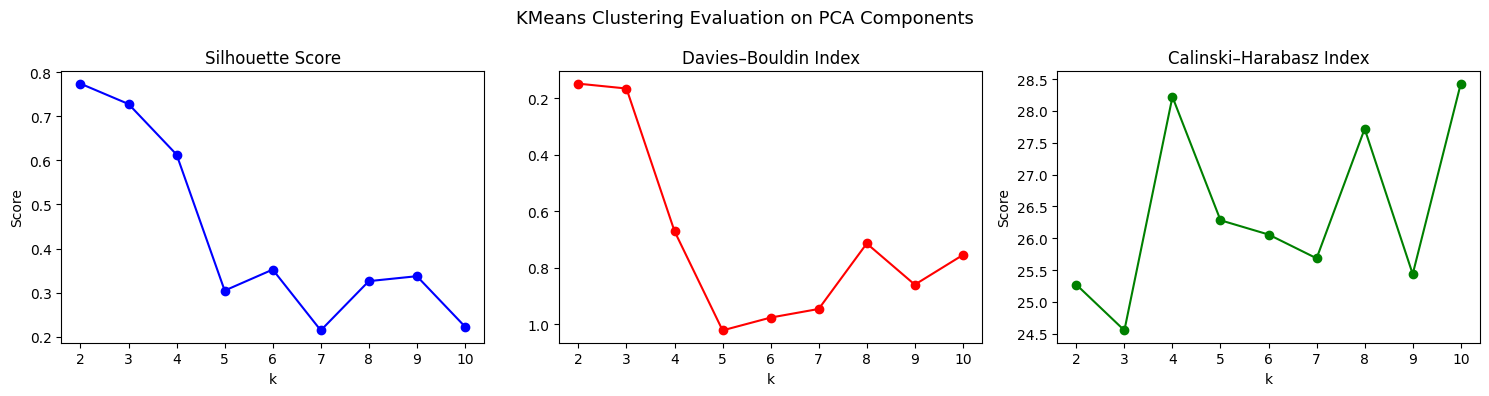


 Best k based on Silhouette = 2

 Outliers detected (13): ['AGRIA', 'ALTHEA', 'ALTUS', 'ATLANTIC', 'CARLITA', 'CLEARWATER R', 'DIAMANT', 'DONALD', 'FELSINA', 'INNOVATOR', 'KENNEBEC', 'LADY CLAIRE', 'VIOLET QUEEN']


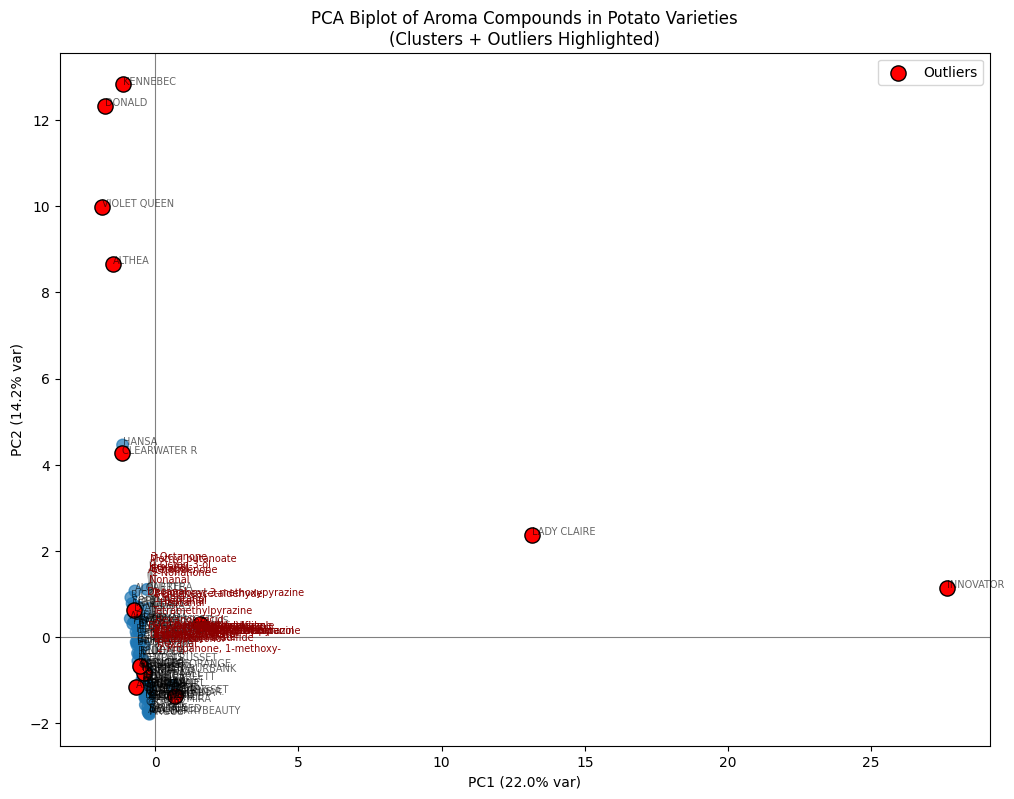


Cluster summary:
Cluster
0    93
1     1
Name: count, dtype: int64

 PCA, clustering, and outlier analysis completed successfully!

Final clustering results:
    Variety  Cluster  is_outlier
0     ADORA        0       False
1     AGRIA        0        True
2  ALOUETTE        0       False
3    ALTHEA        0        True
4   ALTURAS        0       False

 Results saved to 'pca_cluster_results.csv'
Number of detected outliers: 13

Outlier varieties:


,Variety,Cluster,is_outlier
1,AGRIA,0,True
3,ALTHEA,0,True
5,ALTUS,0,True
12,ATLANTIC,0,True
22,CARLITA,0,True
29,CLEARWATER R,0,True
35,DIAMANT,0,True
36,DONALD,0,True
43,FELSINA,0,True
52,INNOVATOR,1,True


In [8]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import  analyze_aroma_clusters

results = analyze_aroma_clusters(aroma_matrix)

# Display summary
print("\nFinal clustering results:")
print(results.head())

# Optionally, save results
results.to_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\pca_cluster_results.csv",
    index=False
)
print("\n Results saved to 'pca_cluster_results.csv'")
#  View detected outliers
outliers_df = results[results["is_outlier"] == True]

print(f"Number of detected outliers: {outliers_df.shape[0]}")
print("\nOutlier varieties:")
display(outliers_df)


Optimal PCA components: 16 (explains 90.2% variance)


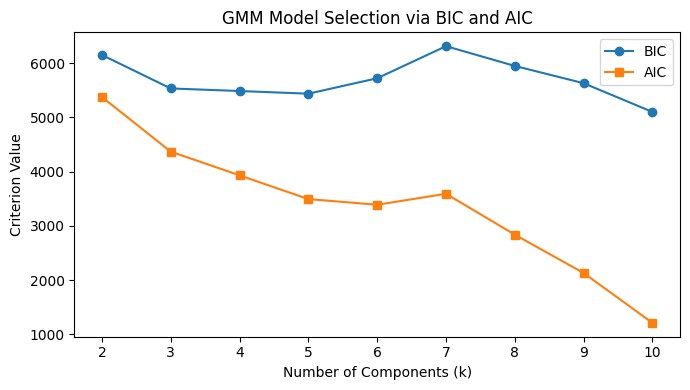

Best number of clusters (based on BIC): 10

Clustering metrics for k=10:
 Silhouette Score:       0.297
 Davies–Bouldin Index:   0.924
 Calinski–Harabasz:      23.2

Outliers detected (13): ['AGRIA', 'ALTHEA', 'ALTUS', 'ATLANTIC', 'CARLITA', 'CLEARWATER R', 'DIAMANT', 'DONALD', 'FELSINA', 'INNOVATOR', 'KENNEBEC', 'LADY CLAIRE', 'VIOLET QUEEN']


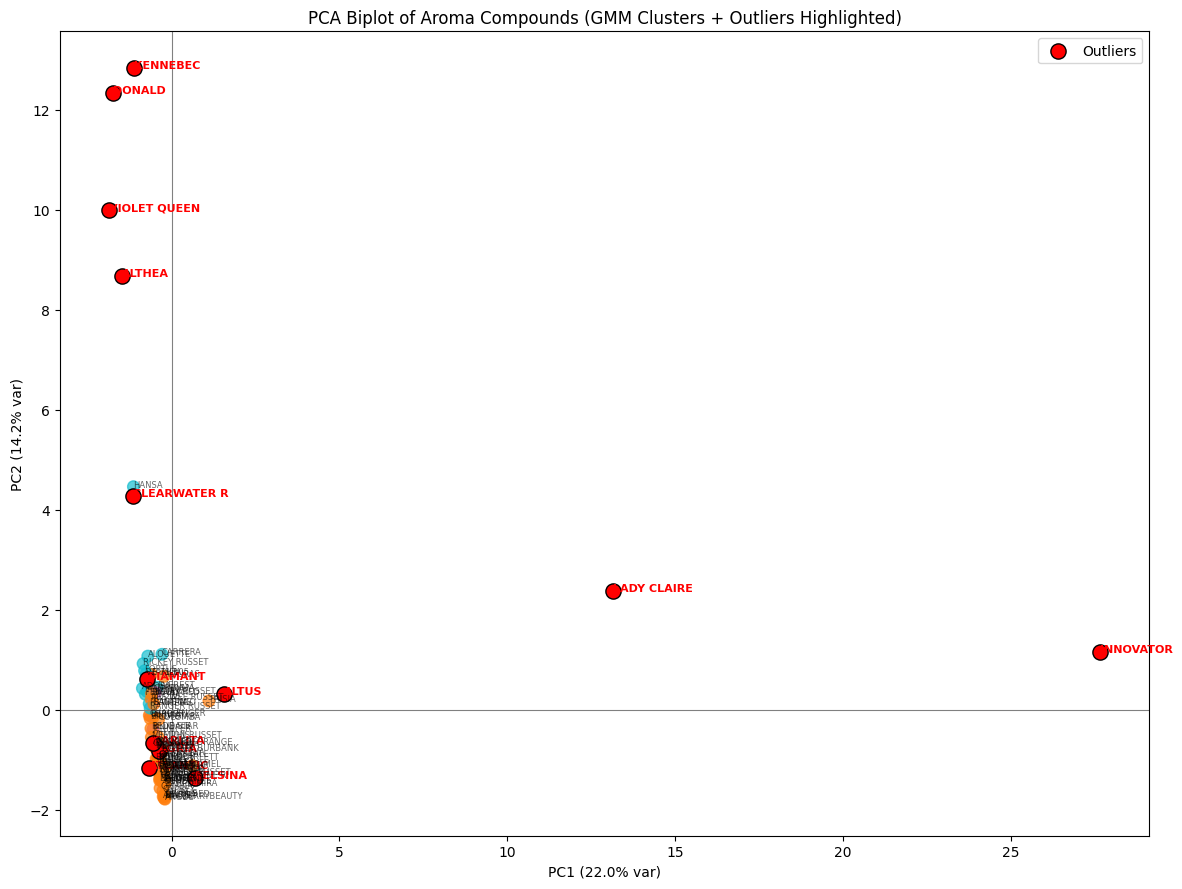

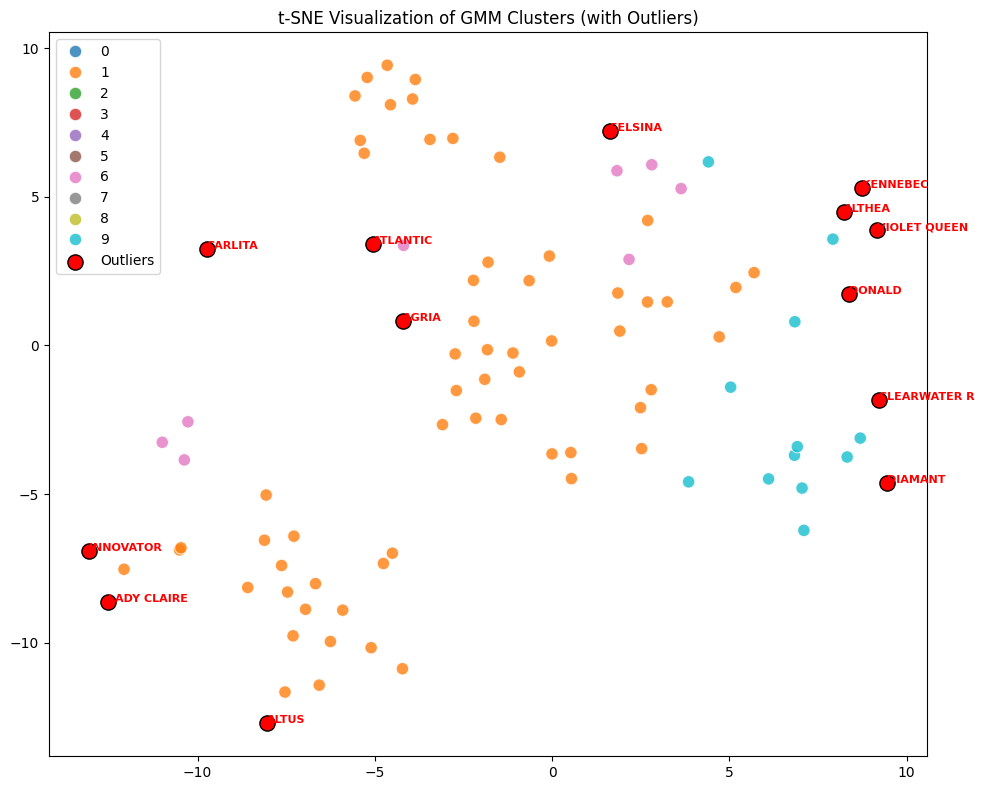

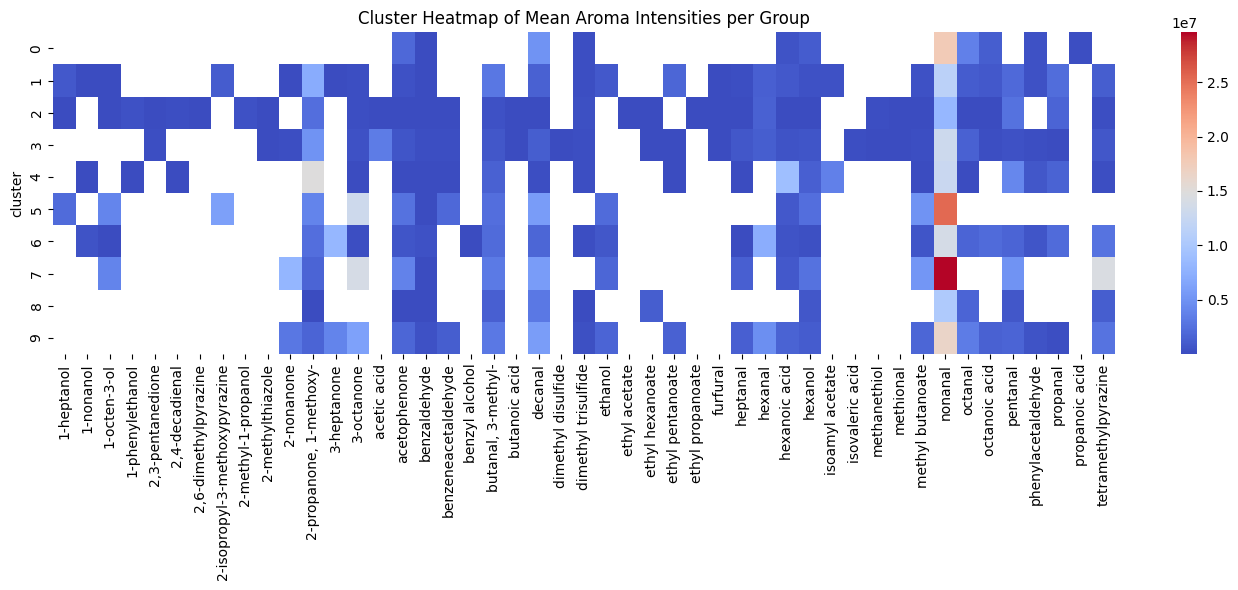


 Results saved in: aroma_cluster_results


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial import distance
from sklearn.manifold import TSNE
import os


def analyze_aroma_clusters_gmm(aroma_matrix, output_dir="aroma_cluster_results"):
    """
    Perform PCA + GMM clustering + outlier detection for aroma compounds.
    Handles both 'Variety' and 'variety' column names automatically.
    """

    os.makedirs(output_dir, exist_ok=True)
    df = aroma_matrix.copy()
    df.columns = [c.strip().lower() for c in df.columns]  # normalize column names

    # --- Handle variety names ---
    if "variety" in df.columns:
        varieties = df["variety"].astype(str).values
    else:
        df = df.reset_index()
        df.rename(columns={df.columns[0]: "variety"}, inplace=True)
        varieties = df["variety"].astype(str).values

    # --- Extract numeric data ---
    X = (
        df.drop(columns=["variety"], errors="ignore")
        .select_dtypes(include=[np.number])
        .fillna(0)
    )
    X_scaled = StandardScaler().fit_transform(X)

    # --- PCA ---
    pca_full = PCA().fit(X_scaled)
    explained = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = np.argmax(explained >= 0.9) + 1
    print(f"Optimal PCA components: {n_comp} (explains {explained[n_comp-1]*100:.1f}% variance)")

    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_scaled)

    # --- GMM model selection ---
    bics, aics = [], []
    k_range = range(2, 11)
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gmm.fit(X_pca)
        bics.append(gmm.bic(X_pca))
        aics.append(gmm.aic(X_pca))

    plt.figure(figsize=(7, 4))
    plt.plot(k_range, bics, marker='o', label='BIC')
    plt.plot(k_range, aics, marker='s', label='AIC')
    plt.title("GMM Model Selection via BIC and AIC")
    plt.xlabel("Number of Components (k)")
    plt.ylabel("Criterion Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "gmm_model_selection.png"), dpi=300)
    plt.show()

    best_k = k_range[np.argmin(bics)]
    print(f"Best number of clusters (based on BIC): {best_k}")

    # --- Fit final GMM ---
    gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
    cluster_labels = gmm.fit_predict(X_pca)

    # --- Evaluate clustering ---
    silhouette = silhouette_score(X_pca, cluster_labels)
    dbi = davies_bouldin_score(X_pca, cluster_labels)
    chi = calinski_harabasz_score(X_pca, cluster_labels)
    print(f"\nClustering metrics for k={best_k}:")
    print(f" Silhouette Score:       {silhouette:.3f}")
    print(f" Davies–Bouldin Index:   {dbi:.3f}")
    print(f" Calinski–Harabasz:      {chi:.1f}")

    # --- Outlier detection ---
    mean_vec = np.mean(X_pca, axis=0)
    cov_matrix = np.cov(X_pca, rowvar=False)
    inv_cov = np.linalg.inv(cov_matrix)
    mahal = [distance.mahalanobis(x, mean_vec, inv_cov) for x in X_pca]
    Q1, Q3 = np.percentile(mahal, [25, 75])
    IQR = Q3 - Q1
    threshold = Q3 + 2 * IQR
    outlier_mask = np.array(mahal) > threshold

    results = pd.DataFrame({
        "Variety": varieties,
        "Cluster": cluster_labels,
        "Mahalanobis": mahal,
        "is_outlier": outlier_mask
    })
    outliers = results.loc[outlier_mask, "Variety"].tolist()
    print(f"\nOutliers detected ({len(outliers)}): {outliers}")

    # --- PCA biplot ---
    loadings = pca.components_.T[:, :2]
    scores = X_pca[:, :2]
    plt.figure(figsize=(12, 9))
    plt.scatter(scores[:, 0], scores[:, 1], c=cluster_labels, cmap="tab10", s=70, alpha=0.7)
    plt.scatter(scores[outlier_mask, 0], scores[outlier_mask, 1],
                color="red", edgecolor="k", s=120, label="Outliers")

    for i, name in enumerate(varieties):
        if name in outliers:
            plt.text(scores[i, 0], scores[i, 1], name, fontsize=8, color='red', weight='bold')
        else:
            plt.text(scores[i, 0], scores[i, 1], name, fontsize=6, alpha=0.6)

    plt.axhline(0, color='gray', lw=0.8)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA Biplot of Aroma Compounds (GMM Clusters + Outliers Highlighted)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "pca_biplot_clusters.png"), dpi=300)
    plt.show()

    # --- t-SNE visualization ---
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    X_tsne = tsne.fit_transform(X_pca)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=cluster_labels, palette="tab10", s=80, alpha=0.8)
    plt.scatter(X_tsne[outlier_mask, 0], X_tsne[outlier_mask, 1], color="red", edgecolor="k", s=120, label="Outliers")

    for i, name in enumerate(varieties):
        if name in outliers:
            plt.text(X_tsne[i, 0], X_tsne[i, 1], name, fontsize=8, color='red', weight='bold')

    plt.title("t-SNE Visualization of GMM Clusters (with Outliers)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "tsne_clusters.png"), dpi=300)
    plt.show()

    # --- Cluster heatmap ---
    df["cluster"] = cluster_labels
    cluster_means = df.groupby("cluster")[X.columns].mean()

    plt.figure(figsize=(14, 6))
    sns.heatmap(cluster_means, cmap="coolwarm", annot=False)
    plt.title("Cluster Heatmap of Mean Aroma Intensities per Group")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "cluster_heatmap.png"), dpi=300)
    plt.show()

    # --- Top volatiles per cluster ---
    top_features = {}
    for cluster in cluster_means.index:
        sorted_feats = cluster_means.loc[cluster].sort_values(ascending=False).head(5)
        top_features[cluster] = list(sorted_feats.index)

    pd.DataFrame.from_dict(top_features, orient="index").to_csv(
        os.path.join(output_dir, "top_features_per_cluster.csv")
    )

    print(f"\n Results saved in: {output_dir}")
    return results, cluster_means


# --- Run function ---
results, cluster_means = analyze_aroma_clusters_gmm(aroma_matrix)


In [9]:
# # ----------------------------------------
# # 🔹 Force clustering to 4 groups (k=4)
# # ----------------------------------------
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# # Apply k-means with 4 clusters
# kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
# cluster_labels_4 = kmeans_4.fit_predict(X_pca)

# # Create result dataframe
# results_4 = pd.DataFrame({
#     "Variety": varieties,
#     "Cluster": cluster_labels_4
# })

# # ----------------------------------------
# # 🔹 Plot PCA biplot with 4 clusters
# # ----------------------------------------
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(
#     X_pca[:, 0], X_pca[:, 1],
#     c=cluster_labels_4, cmap="tab10", s=80, alpha=0.8
# )

# # Add variety names
# for i, name in enumerate(varieties):
#     plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=7, alpha=0.6)

# # Axis & titles
# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
# plt.title("PCA of Potato Aroma Profiles — 4 Fixed Clusters (k=4)")
# plt.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
# plt.grid(alpha=0.4)
# plt.show()

# # Cluster summary
# print("Cluster distribution:")
# print(results_4["Cluster"].value_counts().sort_index())


# Comparative Analysis of Aroma Compound Classes Between Outlier and Inlier Potato Varieties

In [10]:
# import compound_analysis_module
# importlib.reload(compound_analysis_module)
# from compound_analysis_module import  compare_outlier_aroma_profiles
# outliers = ['INNOVATOR', 'LADY CLAIRE']
# compare_outlier_aroma_profiles(aroma_matrix, outliers)


#  Top Contributing Aroma Compounds Based on Mean Intensity


 Total compounds analyzed: 47
 Top 10 aroma compounds by average intensity:

                                      mean         std
Nonanal                        13198803.72  6010340.11
2-Propanone, 1-methoxy-         6063727.71  5796319.97
3-Heptanone                     5420060.05  3594254.86
2-Nonanone                      4520422.56  4196328.76
3-Octanone                      4340795.19  6036327.87
2-Isopropyl-3-methoxypyrazine   3583037.28  3477300.08
Butanal, 3-methyl-              2798065.04  1423738.95
Hexanal                         2507803.98  2964471.87
Decanal                         2414468.73  2302979.66
Pentanal                        2235235.12  1851174.23


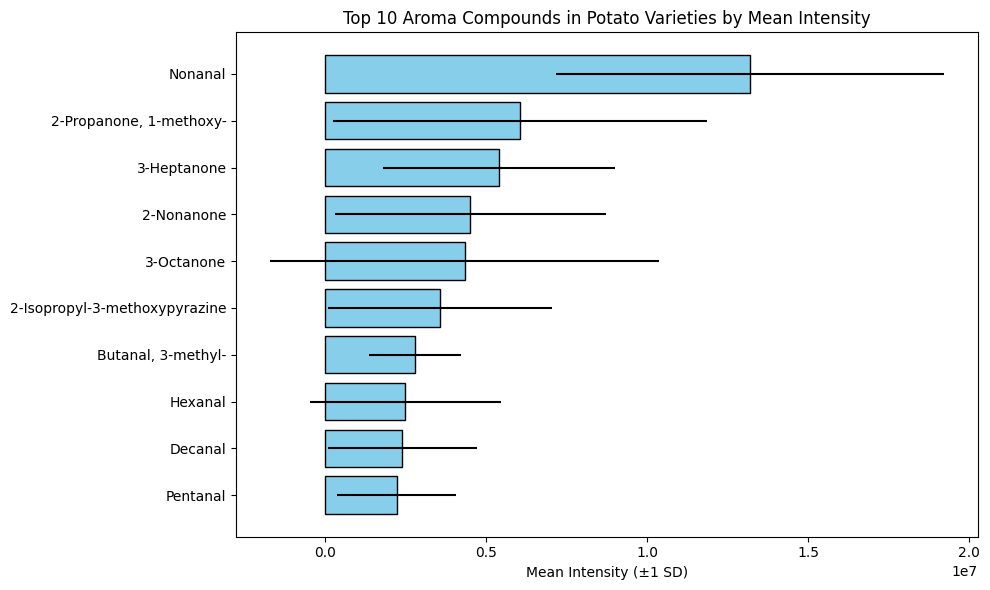

In [11]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(aroma_matrix, top_n=10)



# Heatmap of Top Aroma Compounds in Potato Varieties

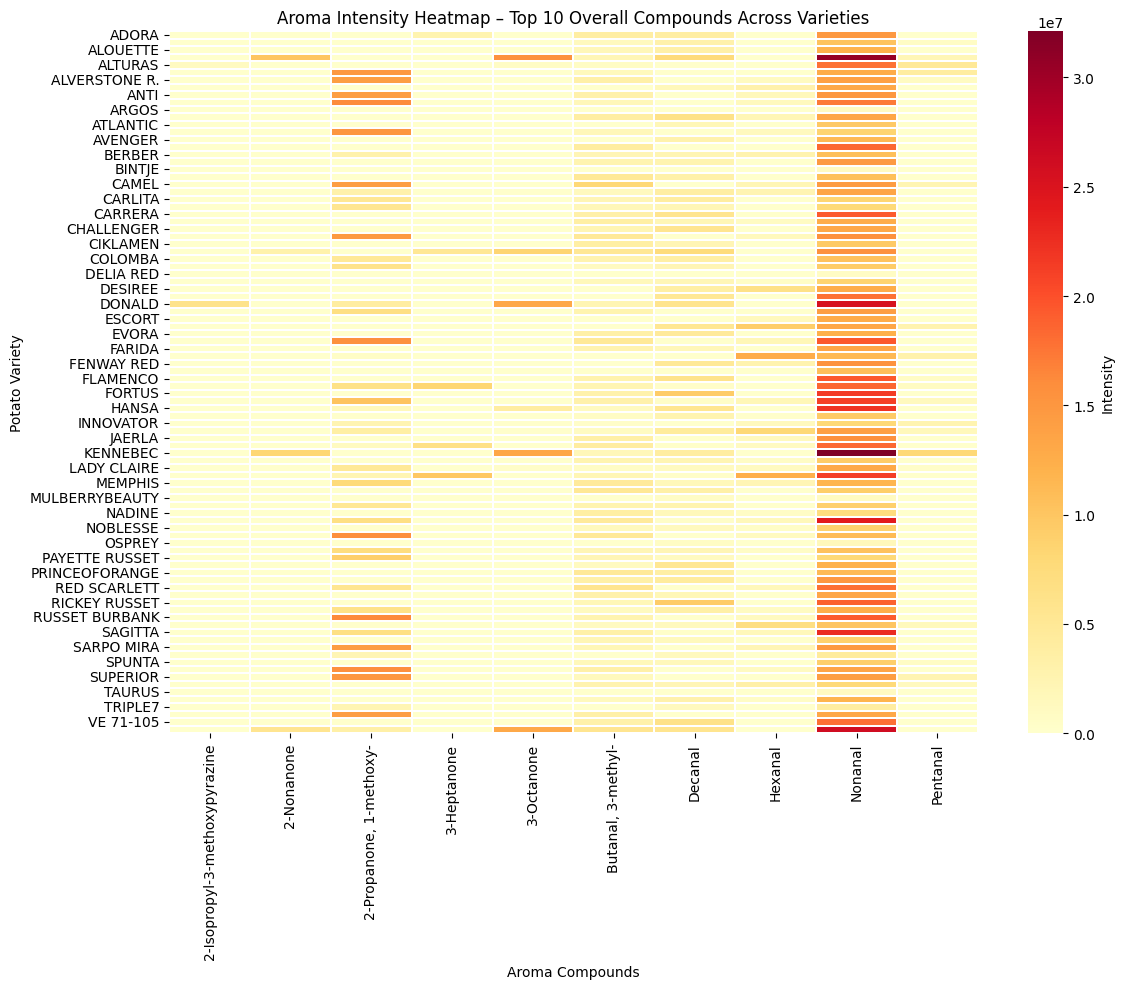

In [12]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_top_aroma_heatmap

# Show top 10 compounds overall across varieties
plot_top_aroma_heatmap(aroma_matrix, top_n=10, mode="overall")

# Interactive Aroma Compound Dashboard for Potato Varieties

In [13]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import launch_aroma_dashboard
launch_aroma_dashboard(aroma_matrix)



 Launching Potato Aroma Dashboard at: http://127.0.0.1:8097


OSError: Address 'http://127.0.0.1:8097' already in use.
    Try passing a different port to run.

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

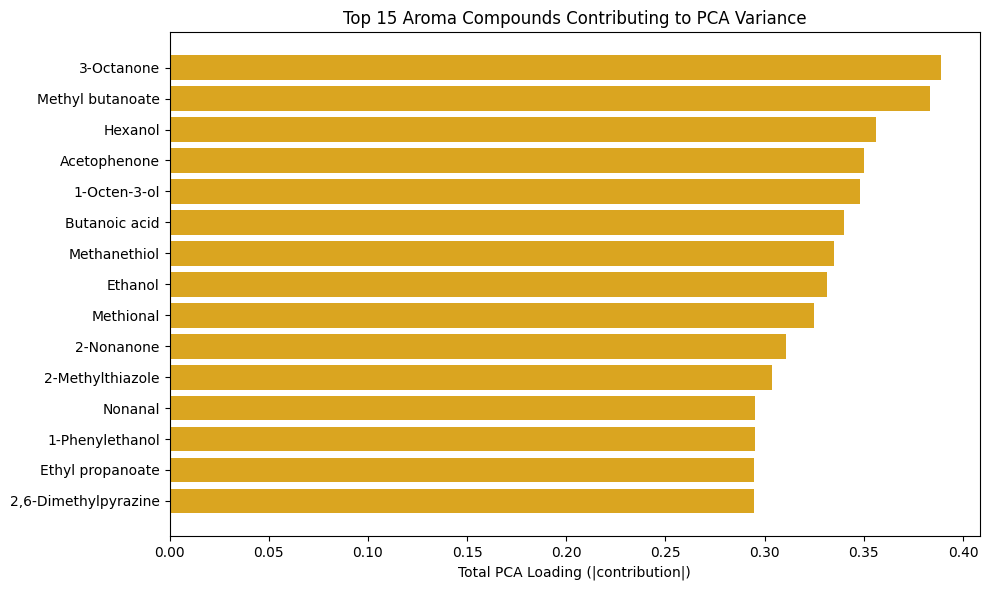

 Top 15 most contributing compounds:
                           PC1       PC2  Total_Importance
3-Octanone            0.031216  0.357929          0.389144
Methyl butanoate      0.034036  0.349162          0.383198
Hexanol               0.044264  0.311736          0.356001
Acetophenone          0.050946  0.299143          0.350089
1-Octen-3-ol          0.026889  0.321056          0.347944
Butanoic acid         0.307883  0.031935          0.339818
Methanethiol          0.305766  0.028998          0.334764
Ethanol               0.029938  0.301754          0.331692
Methional             0.285627  0.039469          0.325096
2-Nonanone            0.025153  0.285695          0.310848
2-Methylthiazole      0.262880  0.040858          0.303739
Nonanal               0.040730  0.254589          0.295319
1-Phenylethanol       0.277273  0.017900          0.295173
Ethyl propanoate      0.276950  0.017801          0.294752
2,6-Dimethylpyrazine  0.276950  0.017801          0.294752


In [14]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_matrix)


# Joining the sensory panel data 

In [15]:
sensory = pd.read_excel(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

In [16]:

import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)
sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

 Rows (unique varieties): 59
 Traits averaged: 20

 Example of summarized sensory data:
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0          

# Predicting the flavors for all the non existing varaieties by using the aroma compounds

# First merge aroma and sensory datasets

In [17]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import merge_aroma_with_sensory


merged_aroma_sensory= merge_aroma_with_sensory(aroma_matrix, sensory_summary)


 Number of merged varieties: 20
Preview of merged data:
     Variety  1-Heptanol  1-Nonanol  1-Octen-3-ol  1-Phenylethanol  \
0      ADORA         NaN        NaN           NaN              NaN   
1      AGRIA         NaN        NaN           NaN              NaN   
2     BERBER         NaN        NaN           NaN              NaN   
3  BILDTSTAR         NaN        NaN           NaN              NaN   
4     BINTJE         NaN        NaN           NaN              NaN   

   2,3-Pentanedione  2,4-Decadienal  2,6-Dimethylpyrazine  \
0               NaN             NaN                   NaN   
1               NaN             NaN                   NaN   
2               NaN             NaN                   NaN   
3               NaN             NaN                   NaN   
4               NaN             NaN                   NaN   

   2-Isopropyl-3-methoxypyrazine  2-Methyl-1-propanol  ...  Sweet Aftertaste  \
0                            NaN                  NaN  ...             1.790

 Found 10 aroma compound columns and 20 sensory columns.
 Showing 10 compounds with |r| > 0.05


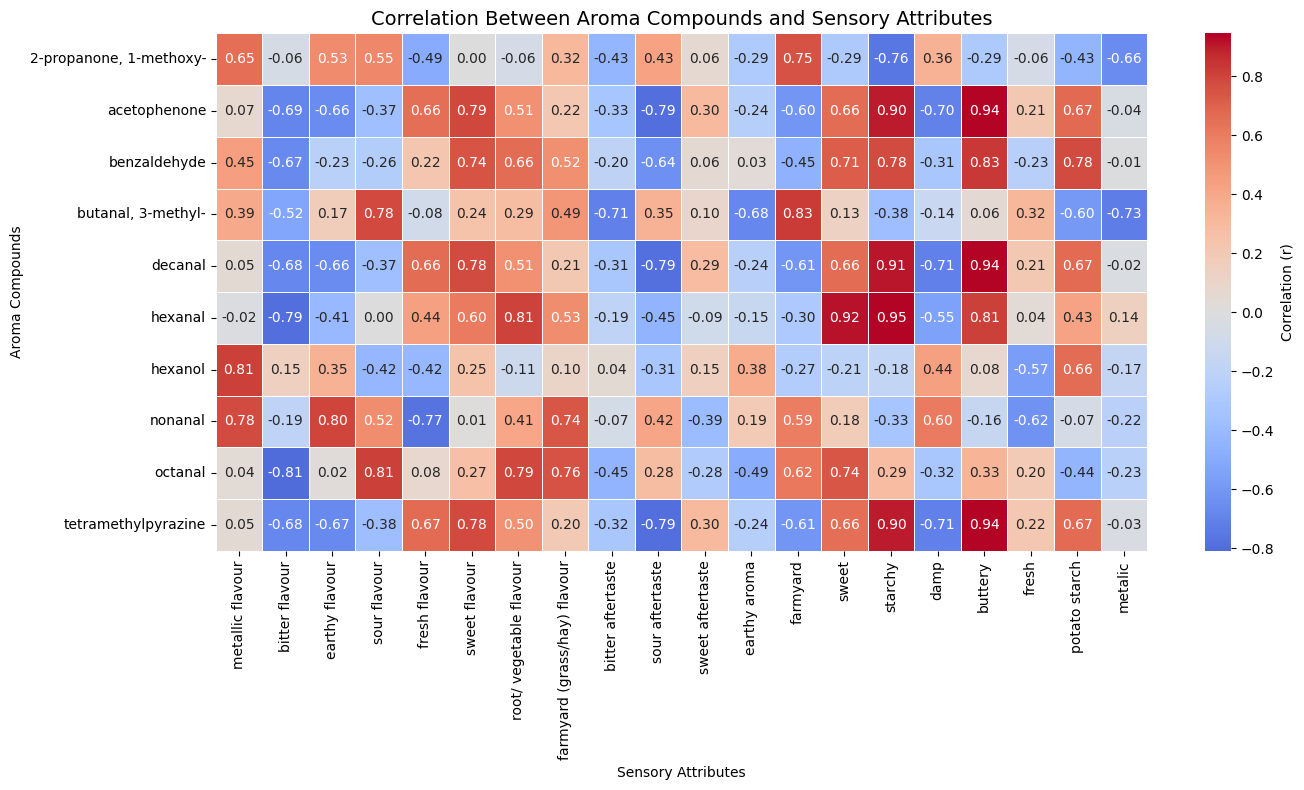

 Correlation matrix saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\compound_sensory_correlation_final.csv


In [18]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import plot_aroma_sensory_correlation
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

corr_block = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    threshold=0.05,
    save_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\compound_sensory_correlation_final.csv"
)


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning:

invalid value encountered in divide

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning:

invalid value encountered in divide



Found 10 strong correlations (|r| ≥ 0.6)
                  Aroma                       Sensory         r
288        BENZALDEHYDE             BITTER AFTERTASTE  0.849685
729  PHENYLACETALDEHYDE               SOUR AFTERTASTE  0.761594
687       OCTANOIC ACID  FARMYARD (GRASS/HAY) FLAVOUR  0.698641
681       OCTANOIC ACID                BITTER FLAVOUR  0.686860
739  PHENYLACETALDEHYDE                       METALIC  0.651088
686       OCTANOIC ACID       ROOT/ VEGETABLE FLAVOUR  0.649708
281        BENZALDEHYDE                BITTER FLAVOUR  0.636908
299        BENZALDEHYDE                       METALIC  0.618338
726  PHENYLACETALDEHYDE       ROOT/ VEGETABLE FLAVOUR  0.615021
722  PHENYLACETALDEHYDE                EARTHY FLAVOUR  0.607609


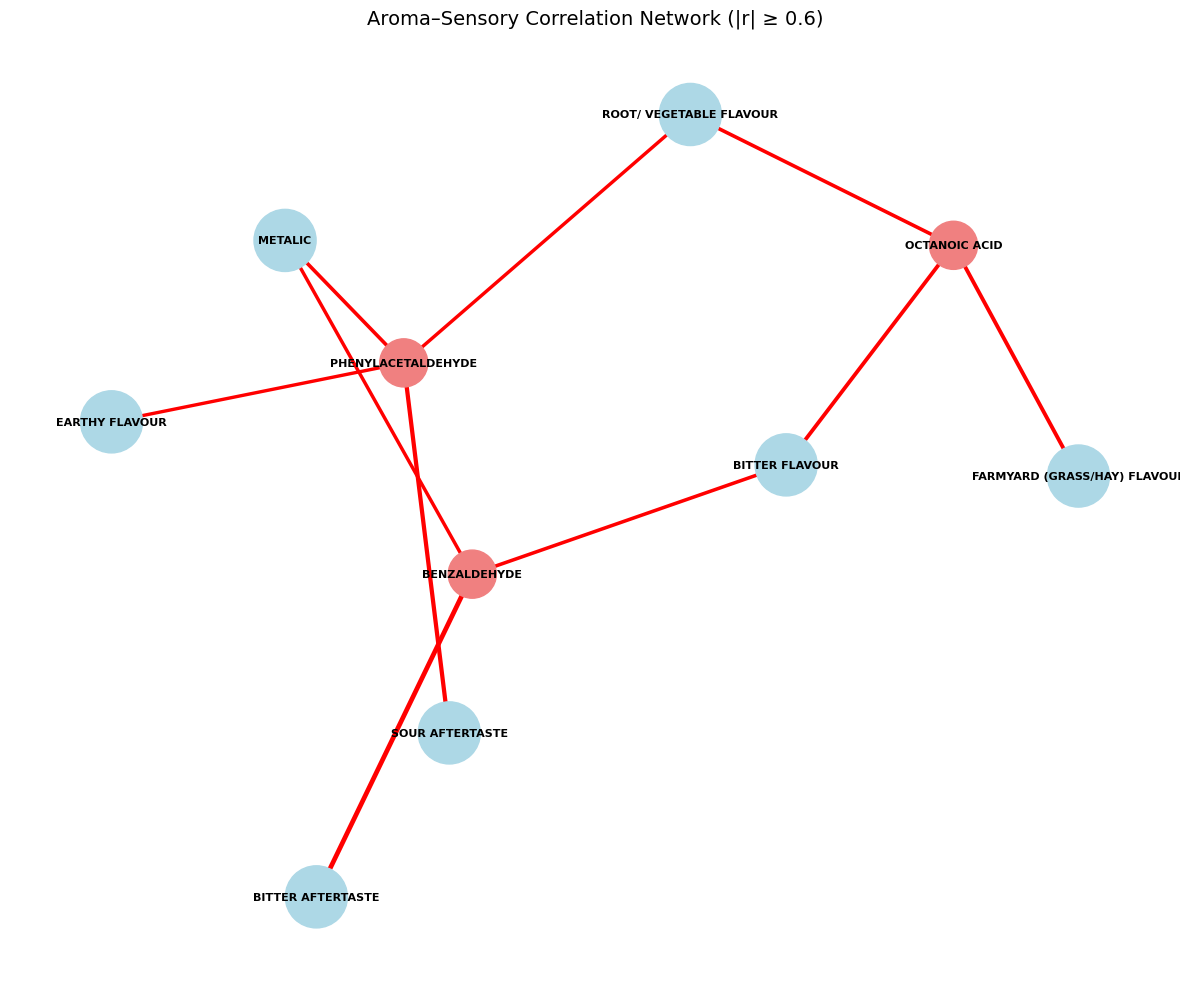

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

def plot_aroma_sensory_network(
    merged_aroma_sensory,
    sensory_cols,
    threshold=0.5
):
    """
    Plot a correlation network between aroma compounds and sensory attributes.

    Parameters
    ----------
    merged_aroma_sensory : pd.DataFrame
        DataFrame containing both aroma compounds and sensory attributes.
    sensory_cols : list
        List of sensory columns to correlate with aroma compounds.
    threshold : float
        Minimum absolute correlation to include in the graph.
    """

    # --- Clean column names ---
    df = merged_aroma_sensory.copy()
    df.columns = df.columns.str.strip().str.upper()
    sensory_cols = [c.upper() for c in sensory_cols]

    # --- Split into aroma and sensory data ---
    aroma_cols = [c for c in df.columns if c not in sensory_cols + ["VARIETY"]]
    aroma_data = df[aroma_cols].select_dtypes(include=[np.number]).fillna(0)
    sensory_data = df[sensory_cols].select_dtypes(include=[np.number]).fillna(0)

    # --- Compute correlation matrix ---
    corr_matrix = pd.DataFrame(
        np.corrcoef(aroma_data.T, sensory_data.T)[:len(aroma_cols), len(aroma_cols):],
        index=aroma_cols,
        columns=sensory_cols
    )

    # --- Flatten correlations ---
    corr_long = corr_matrix.stack().reset_index()
    corr_long.columns = ["Aroma", "Sensory", "r"]

    # Filter based on correlation threshold
    strong_corr = corr_long[np.abs(corr_long["r"]) >= threshold]

    if strong_corr.empty:
        print(f"No correlations found above |r| ≥ {threshold}")
        return

    print(f"Found {len(strong_corr)} strong correlations (|r| ≥ {threshold})")
    print(strong_corr.sort_values("r", ascending=False).head(10))

    # --- Build the network graph ---
    G = nx.Graph()
    for _, row in strong_corr.iterrows():
        G.add_node(row["Aroma"], color="lightcoral", size=1200)
        G.add_node(row["Sensory"], color="lightblue", size=2000)
        G.add_edge(row["Aroma"], row["Sensory"], weight=row["r"])

    # --- Layout and draw ---
    pos = nx.spring_layout(G, k=0.8, seed=42)
    edge_colors = ["red" if w > 0 else "blue" for (_, _, w) in G.edges(data="weight")]
    edge_widths = [abs(w) * 4 for (_, _, w) in G.edges(data="weight")]

    plt.figure(figsize=(12, 10))
    nx.draw_networkx(
        G, pos,
        with_labels=True,
        node_color=[G.nodes[n]["color"] for n in G.nodes()],
        node_size=[G.nodes[n]["size"] for n in G.nodes()],
        edge_color=edge_colors,
        width=edge_widths,
        font_size=8,
        font_weight="bold"
    )
    plt.title(f"Aroma–Sensory Correlation Network (|r| ≥ {threshold})", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
plot_aroma_sensory_network(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=[
        "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
        "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
        "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
        "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
        "Damp","Buttery","Fresh","Potato Starch","Metalic"
    ],
    threshold=0.6  
)


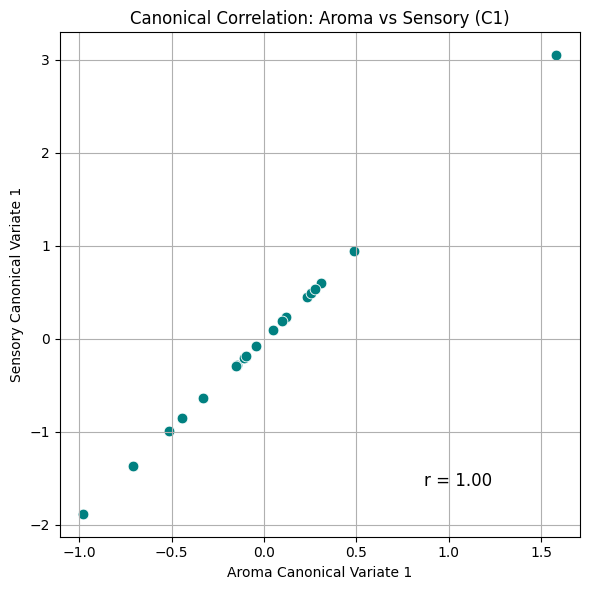

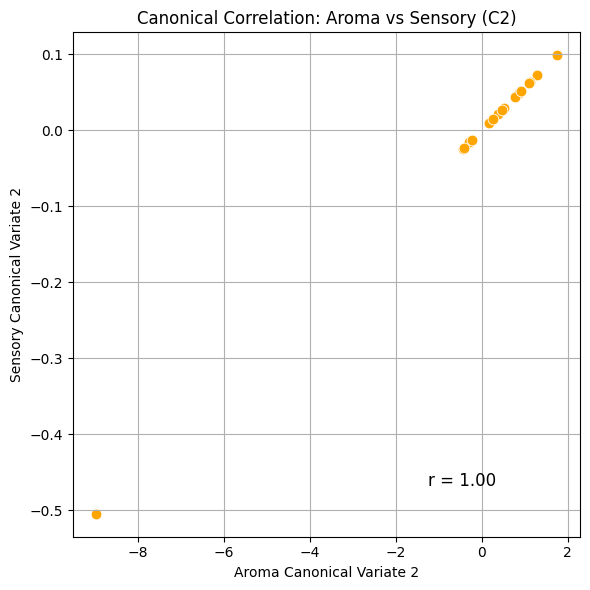

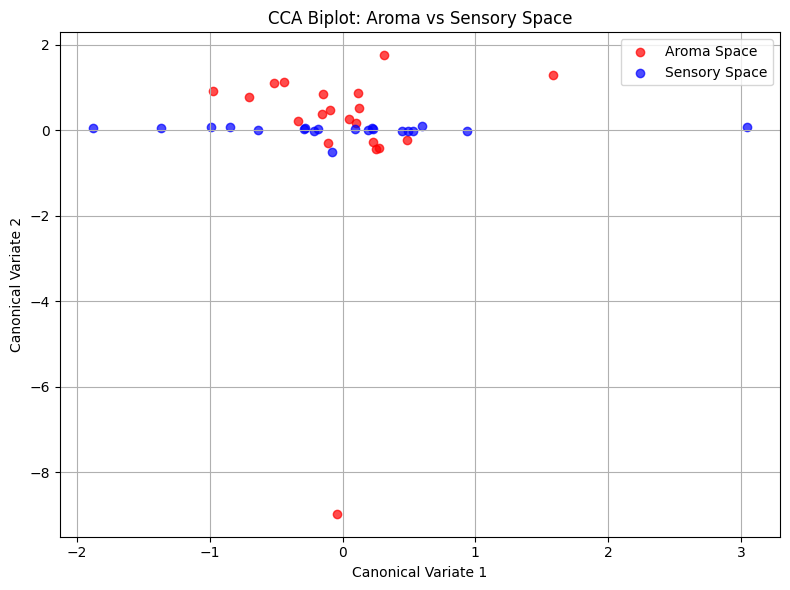

In [23]:
from sklearn.cross_decomposition import CCA
  # --- Clean column names ---
df = merged_aroma_sensory.copy()
df.columns = df.columns.str.strip().str.upper()
sensory_cols = [c.upper() for c in sensory_cols]

    # --- Split into aroma and sensory data ---
aroma_cols = [c for c in df.columns if c not in sensory_cols + ["VARIETY"]]
aroma_data = df[aroma_cols].select_dtypes(include=[np.number]).fillna(0)
sensory_data = df[sensory_cols].select_dtypes(include=[np.number]).fillna(0)

# --- Standardize data (recommended for CCA) ---
X = StandardScaler().fit_transform(aroma_data)
Y = StandardScaler().fit_transform(sensory_data)

# --- Fit CCA ---
cca = CCA(n_components=2)
X_c, Y_c = cca.fit_transform(X, Y)

# --- Create DataFrames for plotting ---
cca_df = pd.DataFrame({
    'Aroma_C1': X_c[:, 0],
    'Aroma_C2': X_c[:, 1],
    'Sensory_C1': Y_c[:, 0],
    'Sensory_C2': Y_c[:, 1]
})

# Plot correlation between canonical variates ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=cca_df['Aroma_C1'], y=cca_df['Sensory_C1'], s=60, color='teal')
plt.xlabel("Aroma Canonical Variate 1")
plt.ylabel("Sensory Canonical Variate 1")
plt.title("Canonical Correlation: Aroma vs Sensory (C1)")
r1 = np.corrcoef(cca_df['Aroma_C1'], cca_df['Sensory_C1'])[0, 1]
plt.text(0.7, 0.1, f"r = {r1:.2f}", transform=plt.gca().transAxes, fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

#  Plot canonical variate 2 (C2) correlation ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=cca_df['Aroma_C2'], y=cca_df['Sensory_C2'], s=60, color='orange')
plt.xlabel("Aroma Canonical Variate 2")
plt.ylabel("Sensory Canonical Variate 2")
plt.title("Canonical Correlation: Aroma vs Sensory (C2)")
r2 = np.corrcoef(cca_df['Aroma_C2'], cca_df['Sensory_C2'])[0, 1]
plt.text(0.7, 0.1, f"r = {r2:.2f}", transform=plt.gca().transAxes, fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

#  Combined projection plot (both pairs) ---
plt.figure(figsize=(8, 6))
plt.scatter(cca_df['Aroma_C1'], cca_df['Aroma_C2'], c='red', alpha=0.7, label='Aroma Space')
plt.scatter(cca_df['Sensory_C1'], cca_df['Sensory_C2'], c='blue', alpha=0.7, label='Sensory Space')
plt.xlabel("Canonical Variate 1")
plt.ylabel("Canonical Variate 2")
plt.title("CCA Biplot: Aroma vs Sensory Space")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


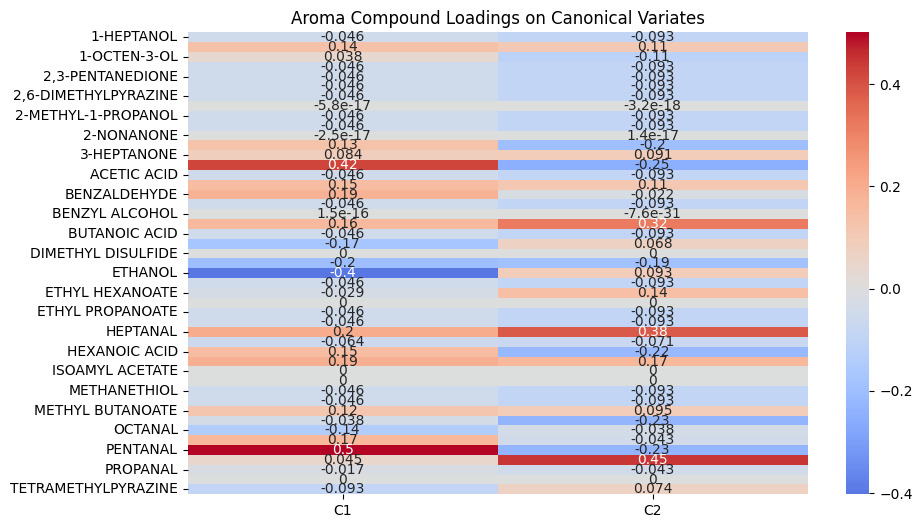

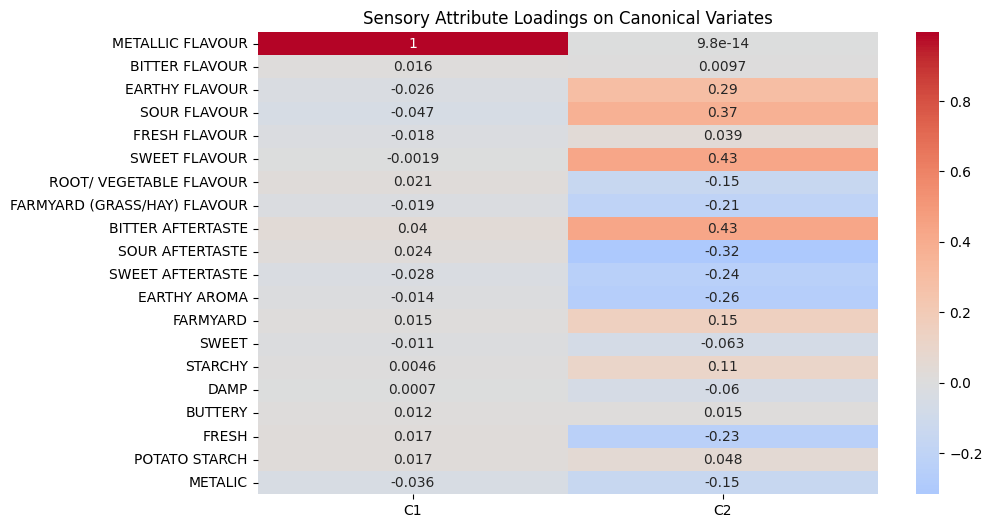

In [24]:
loadings_X = pd.DataFrame(cca.x_weights_, index=aroma_data.columns, columns=['C1', 'C2'])
loadings_Y = pd.DataFrame(cca.y_weights_, index=sensory_data.columns, columns=['C1', 'C2'])

import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(loadings_X, cmap="coolwarm", center=0, annot=True)
plt.title("Aroma Compound Loadings on Canonical Variates")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(loadings_Y, cmap="coolwarm", center=0, annot=True)
plt.title("Sensory Attribute Loadings on Canonical Variates")
plt.show()


# predicting the sensory by aroma compounds using various models

# PLSR MOdel + MAF score

✅ Training with 20 samples, 3 aroma features, and 20 sensory traits.

 R² scores for each sensory trait:
               Sensory Attribute        R²
8              Bitter Aftertaste  0.763497
1                 Bitter Flavour  0.551256
19                       Metalic  0.487469
0               Metallic Flavour  0.416149
7   Farmyard (grass/hay) flavour  0.378585
9                Sour Aftertaste  0.331311
3                   Sour Flavour  0.292892
2                 Earthy Flavour  0.274667
14                       Starchy  0.219666
6        Root/ Vegetable Flavour  0.205470
15                          Damp  0.203493
4                  Fresh Flavour  0.187080
18                 Potato Starch  0.150950
11                  Earthy Aroma  0.122816
10              Sweet Aftertaste  0.121245
5                  Sweet Flavour  0.111771
13                         Sweet  0.064059
16                       Buttery  0.057471
17                         Fresh  0.053799
12                      Farmyard  0

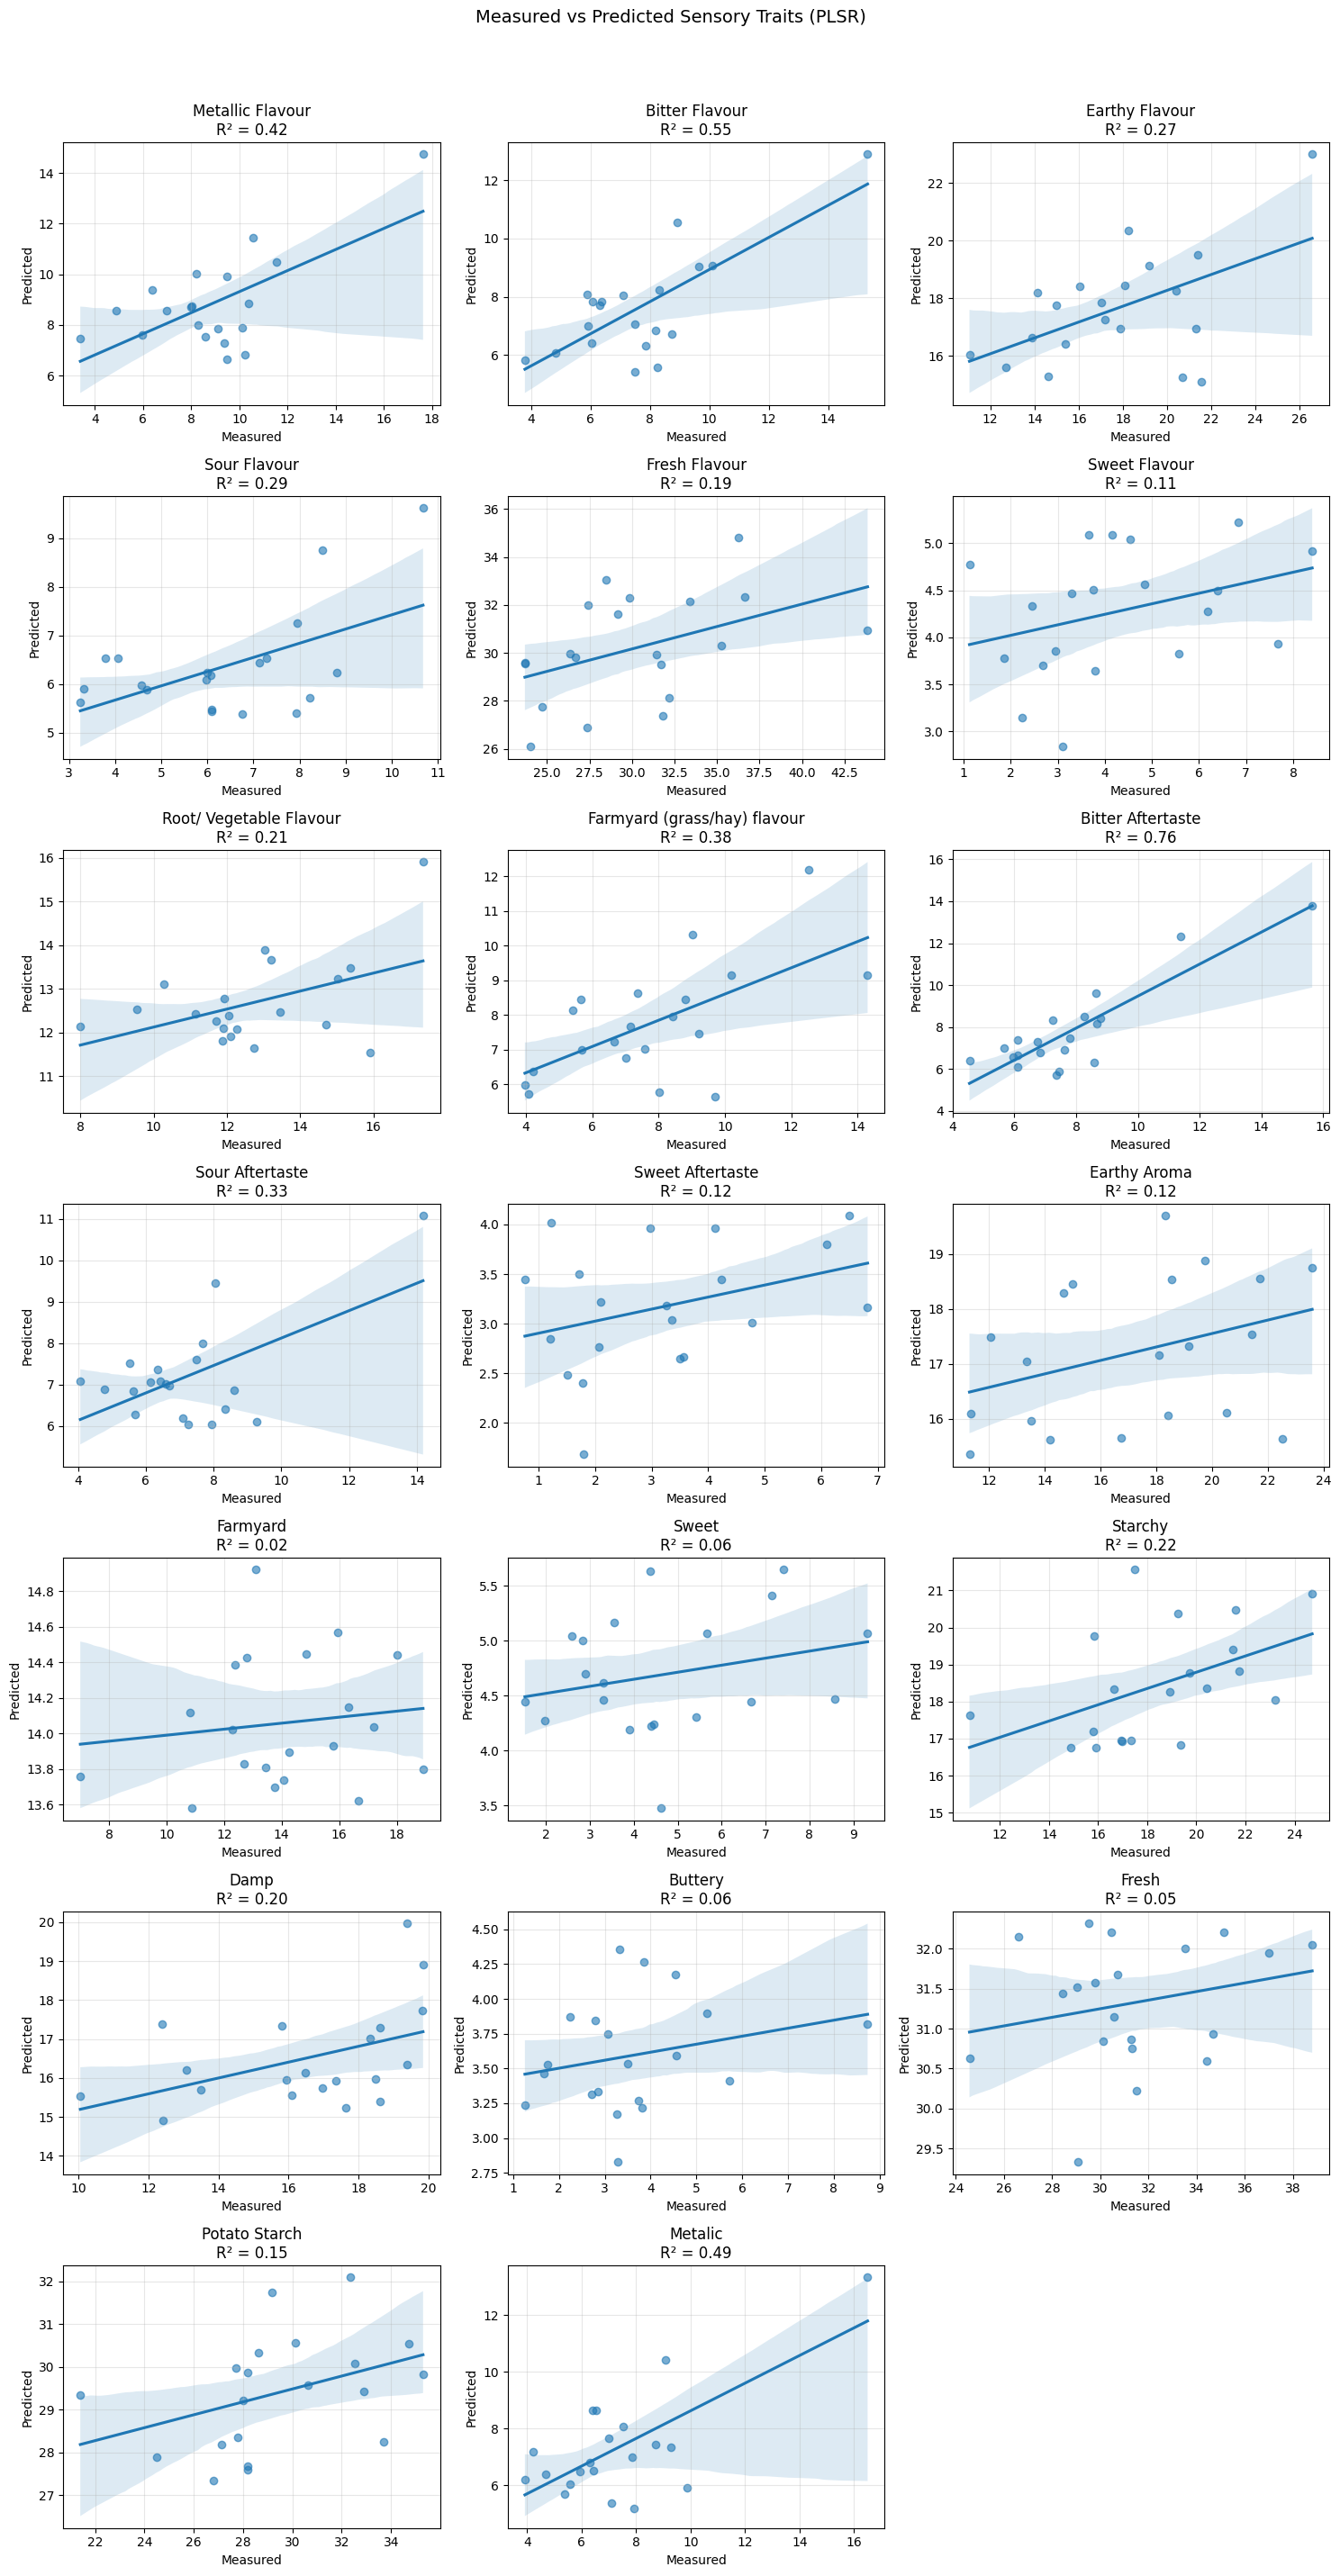

In [19]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_plsr
predicted_df = predict_sensory_from_plsr(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_matrix,
    sensory_cols=sensory_cols,
    n_components=3
)


# Random Forest Regressor prediction


🌿 Random Forest - Top 10 Varieties by Predicted Overall Flavor:
          variety  maf_score
0           ADORA  14.873648
29   CLEARWATER R  14.445473
92      VE 71-105  14.259874
76  RICKEY RUSSET  14.114801
11        ARIZONA  14.090879
39        EVEREST  14.040487
44     FENWAY RED  13.986692
73  RANGER RUSSET  13.881326
61       MONALISA  13.763774
35        DIAMANT  13.615818


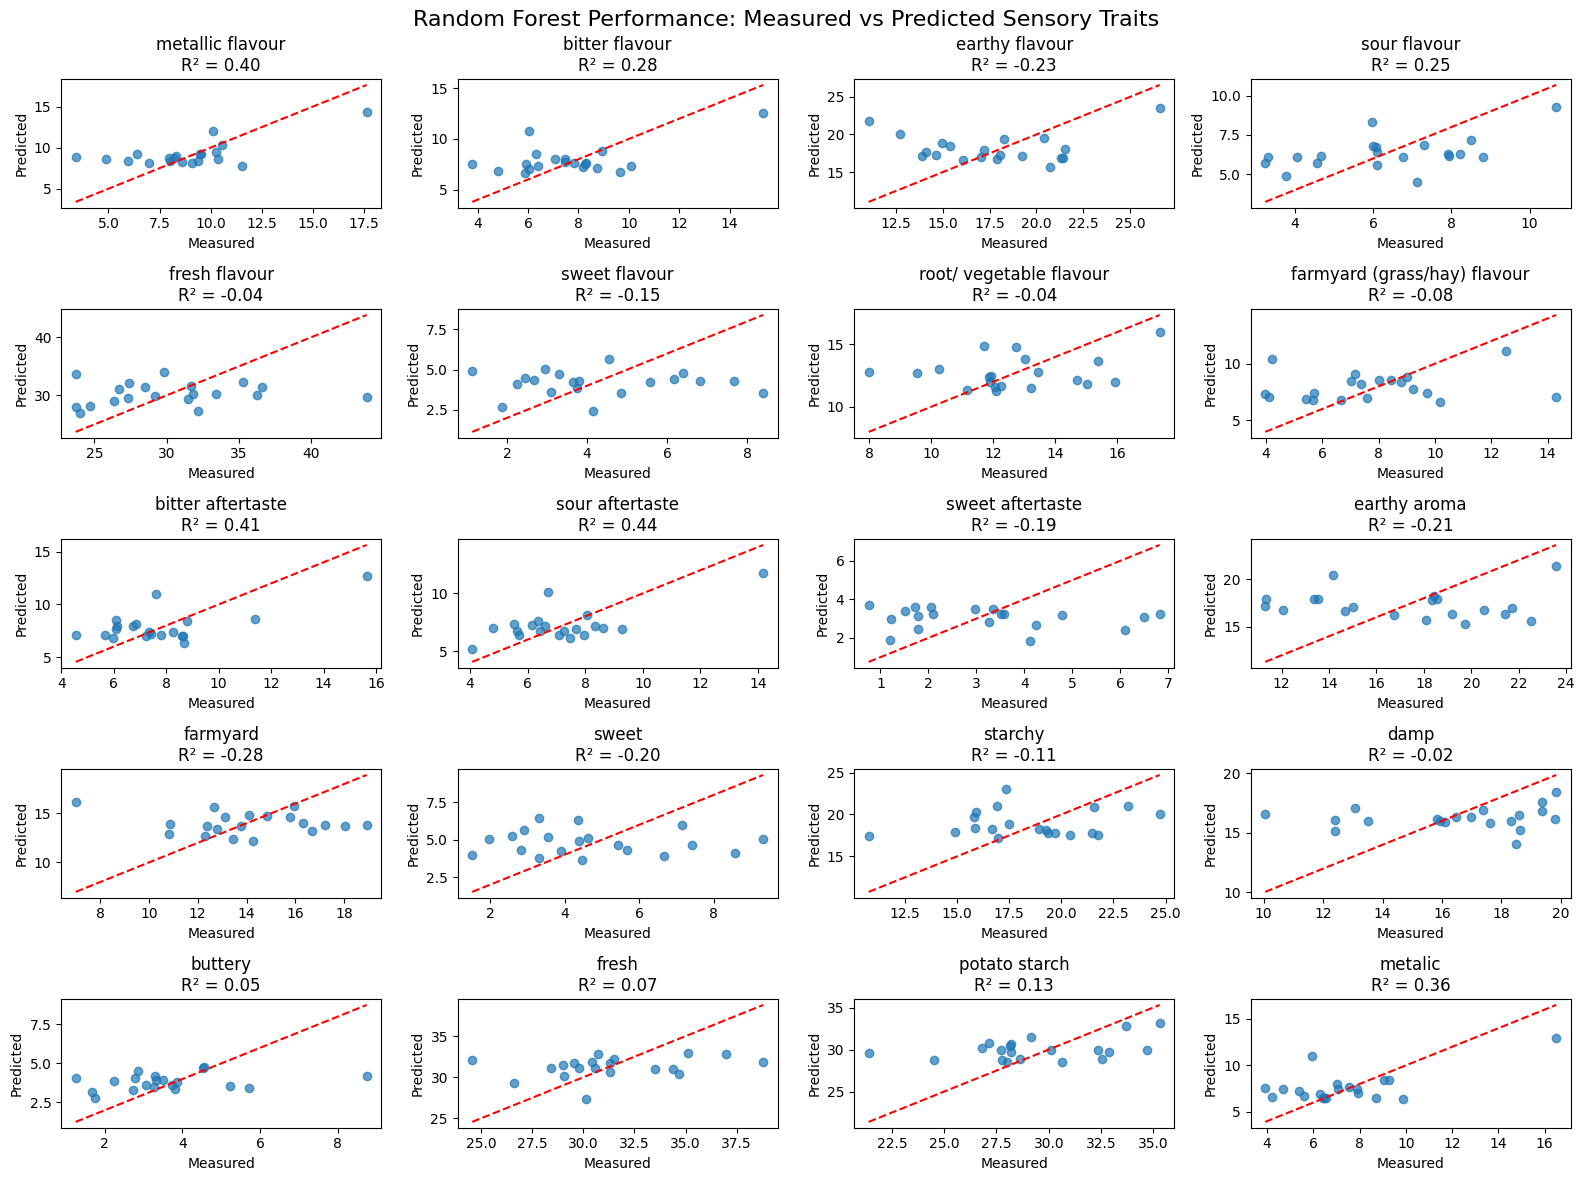

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_random_forest
rf_results = predict_sensory_from_random_forest(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_matrix,
    sensory_cols=sensory_cols
)



# Elasticnet prediction


 ElasticNet - Top 10 Predicted Varieties by Mean Flavor Score:
         Variety  MAF_score
44    FENWAY RED  45.042702
56      KENNEBEC  30.108601
36        DONALD  29.905153
93  VIOLET QUEEN  28.409246
12      ATLANTIC  27.570704
29  CLEARWATER R  23.555952
3         ALTHEA  19.441711
5          ALTUS  19.177869
39       EVEREST  15.708606
92     VE 71-105  15.654418


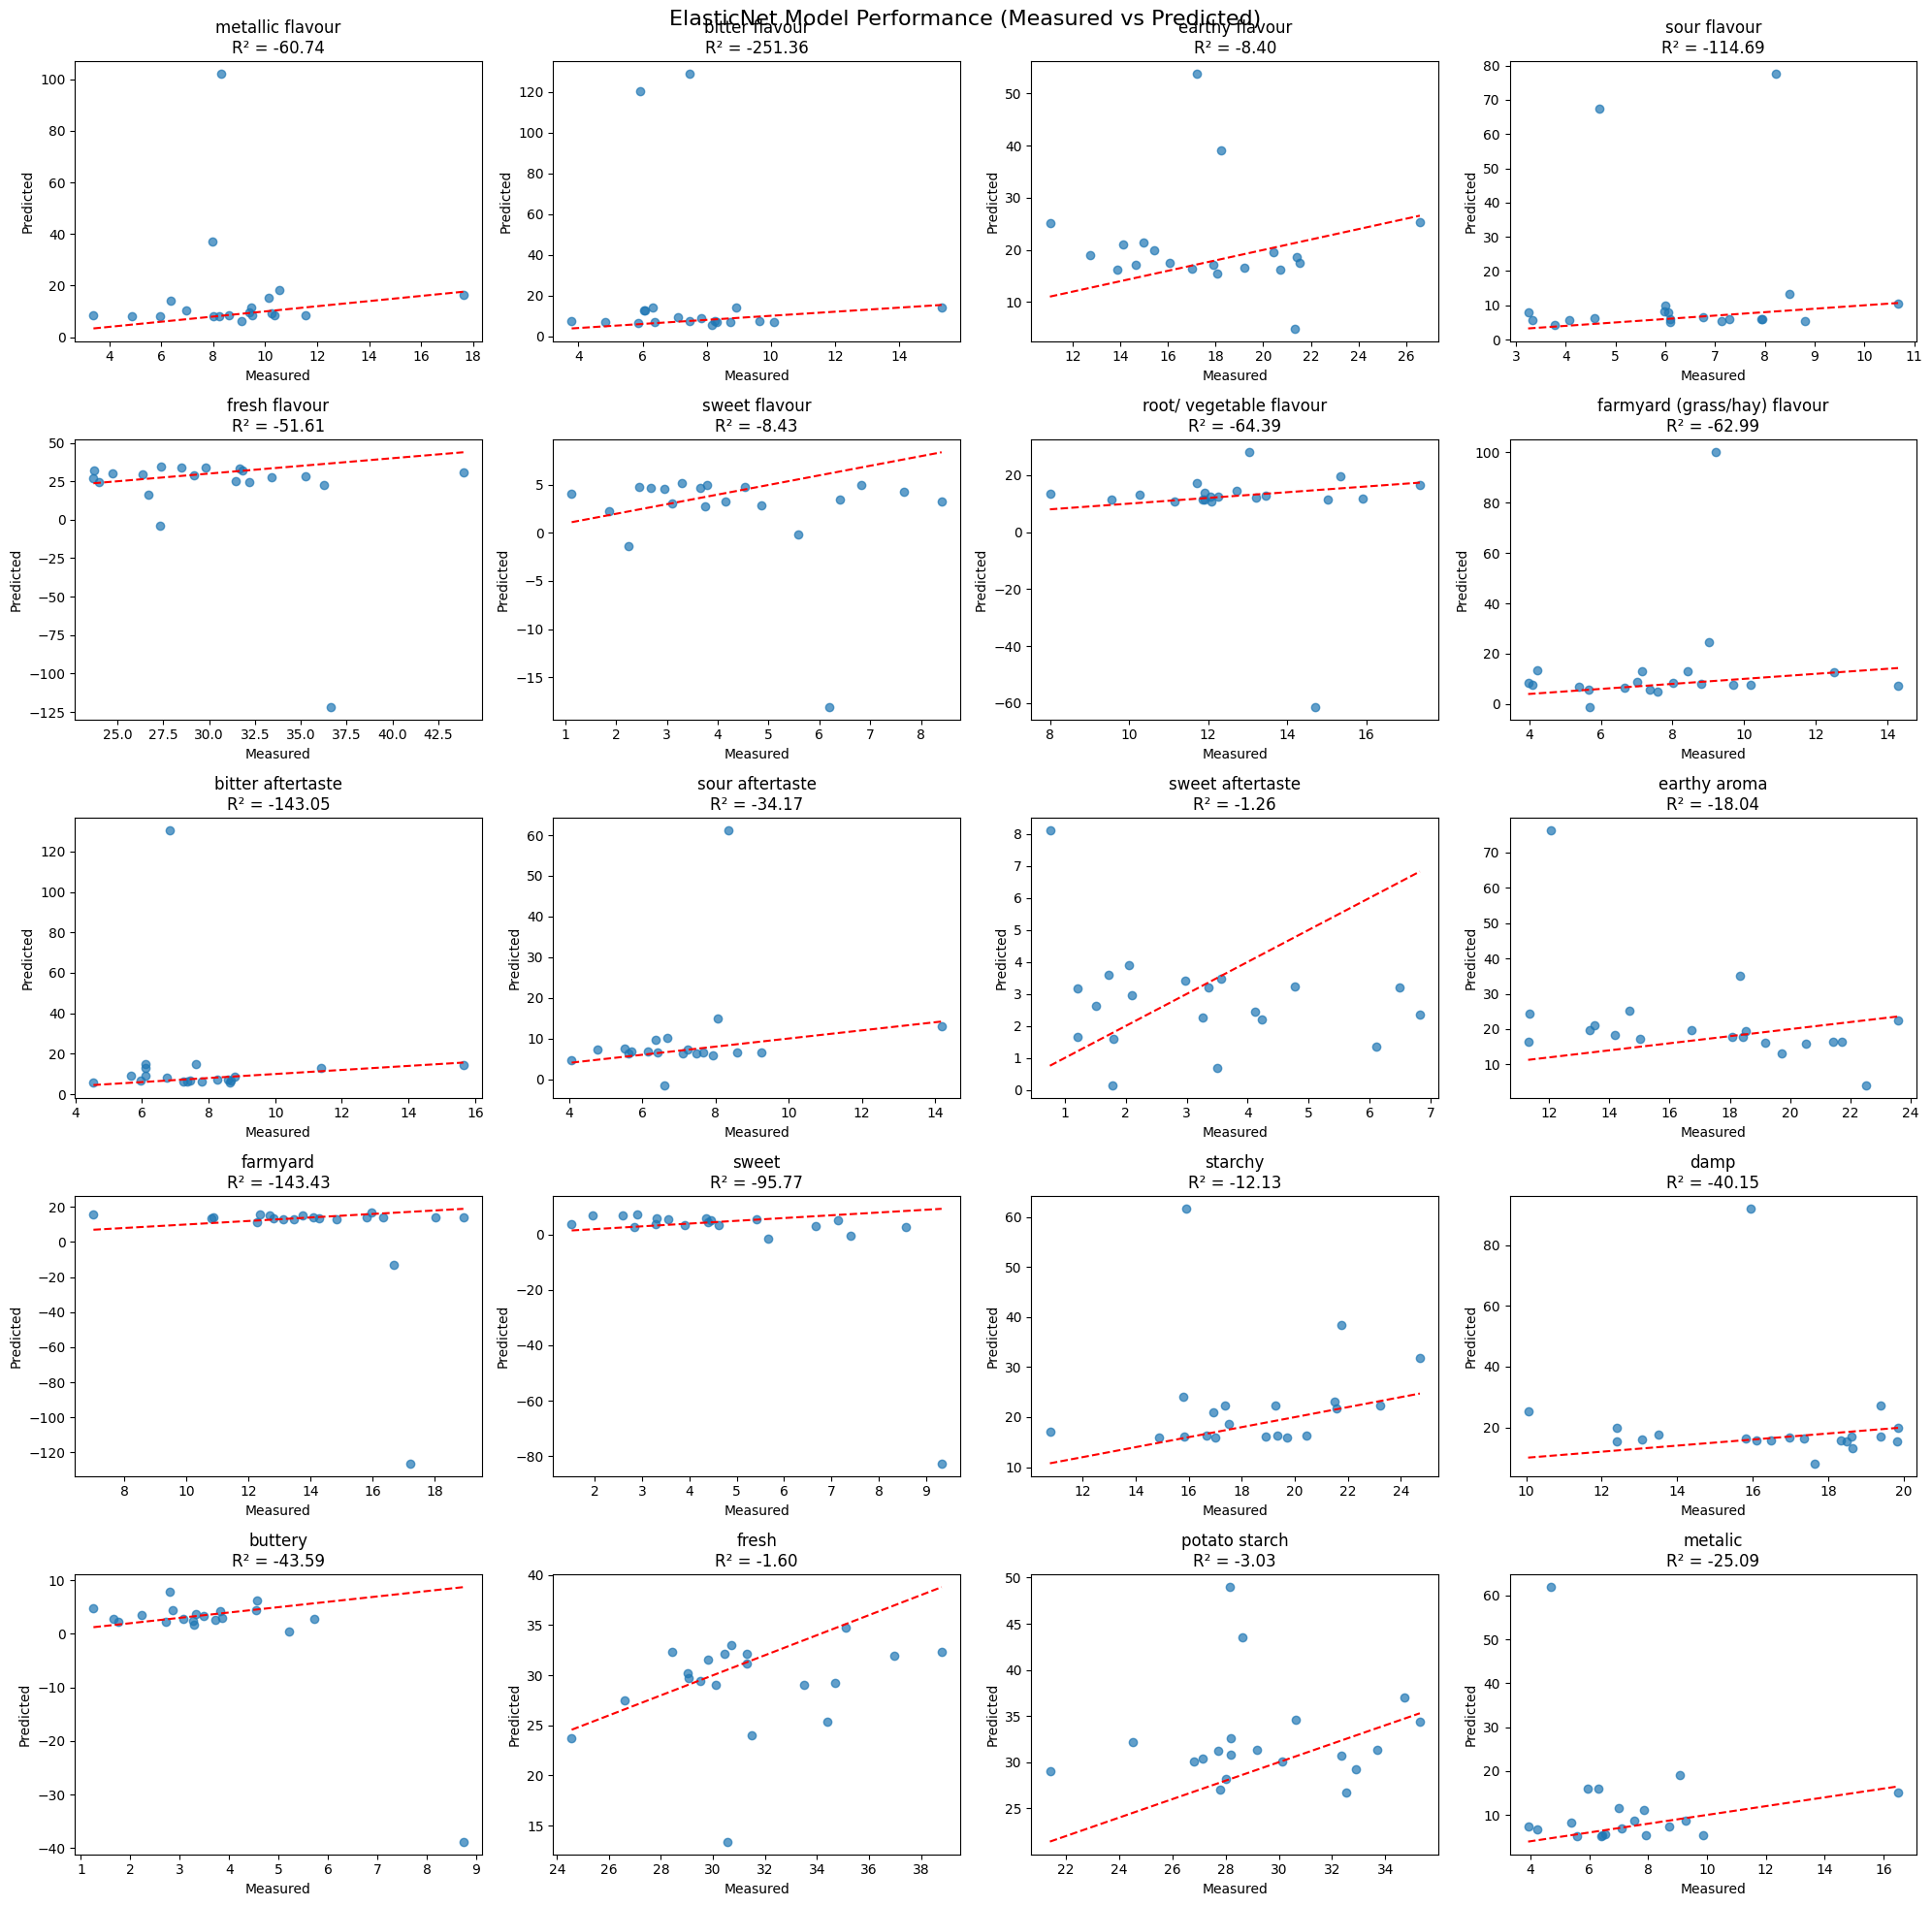

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import predict_sensory_from_elasticnet
elastic_df = predict_sensory_from_elasticnet(
    merged_aroma_sensory=merged_aroma_sensory,
    aroma_matrix=aroma_matrix,
    sensory_cols=sensory_cols
)


# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA


 PCA explained variance ratio: [0.449 0.194 0.089]
 Total projected varieties: 94


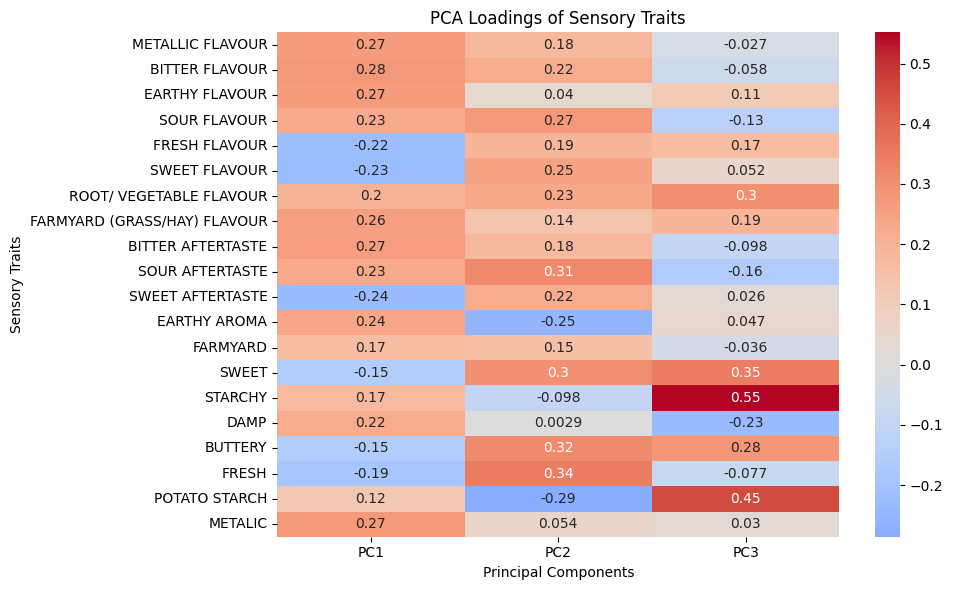

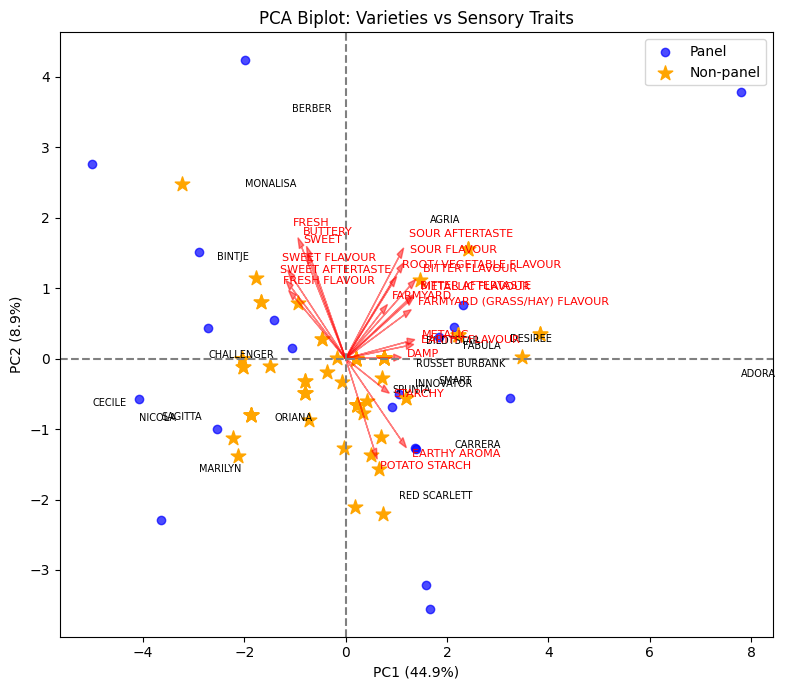

 Projection data saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\sensory_pca_projection_knn.csv
 Loadings saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\sensory_pca_loadings.csv


In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import perform_knn_sensory_projection

pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_matrix,
    sensory_summary=sensory_summary,
    k=3,
    n_components=3,
    scaling_factor=5,
    save_projection_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\sensory_pca_projection_knn.csv",
    save_loadings_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\sensory_pca_loadings.csv"
)




# PCA-Based Sensory Profile Summary of Potato Varieties

In [ ]:
import compound_analysis_module
importlib.reload(compound_analysis_module)
from compound_analysis_module import interpret_variety_sensory_profile
summary_df = interpret_variety_sensory_profile(
    pc_df,
    pc1_thresh=1.5,
    pc2_thresh=1.0,
    save_path=r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\bio_rep1\variety_sensory_summary.csv"
)




 Sensory interpretation summary:
                 PC1       PC2                        Dominant Sensory Axis
Variety                                                                    
ADORA       7.797793  3.786555     Bitter / Sour / Metallic + Sweet / Fresh
AGRIA       1.658722 -3.556767  Bitter / Sour / Metallic + Earthy / Vegetal
BERBER     -1.051535  0.145923                                 Unclassified
BILDTSTAR   1.577946 -3.208374  Bitter / Sour / Metallic + Earthy / Vegetal
BINTJE     -2.531821 -0.997265                           Mild / Less Bitter
CARRERA     2.147434  0.451214                     Bitter / Sour / Metallic
CECILE     -5.000658  2.756226           Mild / Less Bitter + Sweet / Fresh
CHALLENGER -2.706073  0.430283                           Mild / Less Bitter
DESIREE     3.236574 -0.560895                     Bitter / Sour / Metallic
FABULA      2.316093  0.765887                     Bitter / Sour / Metallic
INNOVATOR   1.366099 -1.273287                        


PCA explained variance ratio: [0.449 0.194 0.089]


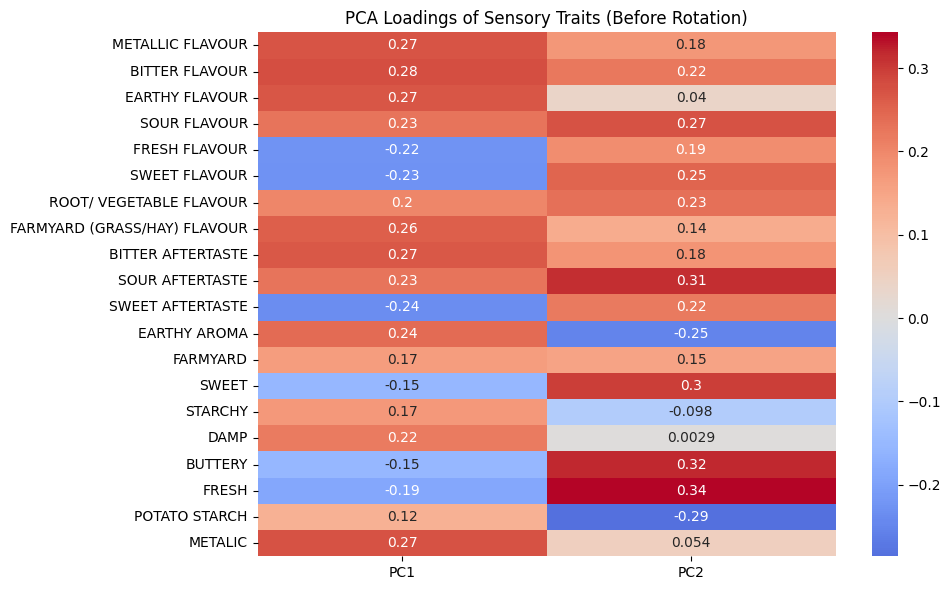

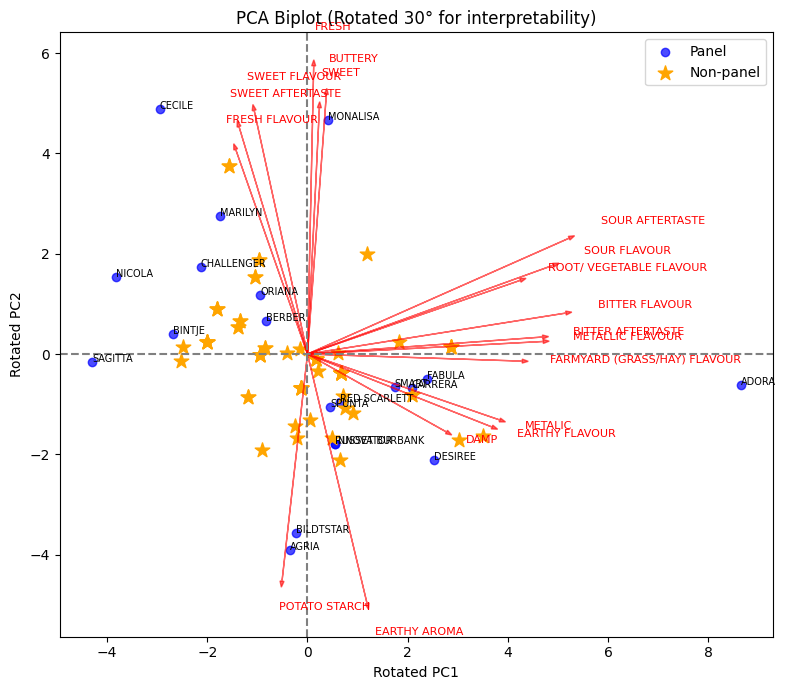

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import os

def perform_knn_sensory_projection_rotatable(
    aroma_matrix,
    sensory_summary,
    k=3,
    n_components=3,
    scaling_factor=4,
    loading_threshold=0.2,
    rotation_angle=0,  # <--- NEW PARAMETER
    save_projection_path=None,
    save_loadings_path=None
):
    """
    Merge aroma + sensory data, impute missing sensory traits using KNN,
    perform PCA on sensory traits, visualize projection, loadings heatmap, and biplot.
    Now includes optional rotation for better interpretability.
    """

    # --- Step 1: Standardize column names ---
    aroma_matrix = aroma_matrix.copy()
    sensory_summary = sensory_summary.copy()
    aroma_matrix.columns = aroma_matrix.columns.str.strip().str.upper()
    sensory_summary.columns = sensory_summary.columns.str.strip().str.upper()

    # --- Step 2: Check for Variety column ---
    if "VARIETY" not in aroma_matrix.columns:
        raise KeyError(" 'VARIETY' column not found in aroma_matrix!")
    if "VARIETY" not in sensory_summary.columns:
        raise KeyError(" 'VARIETY' column not found in sensory_summary!")

    # --- Step 3: Merge datasets ---
    merged = aroma_matrix.merge(sensory_summary, on="VARIETY", how="left")
    merged["IS_PANEL"] = merged["VARIETY"].isin(sensory_summary["VARIETY"])

    panel_df = merged[merged["IS_PANEL"]].reset_index(drop=True)
    nonpanel_df = merged[~merged["IS_PANEL"]].reset_index(drop=True)

    sensory_cols = [c for c in sensory_summary.columns if c != "VARIETY"]
    aroma_cols = [c for c in aroma_matrix.columns if c != "VARIETY"]

    Y_panel = panel_df[sensory_cols].fillna(0)
    X_panel = panel_df[aroma_cols].fillna(0)
    X_nonpanel = nonpanel_df[aroma_cols].fillna(0)

    # --- Step 4: KNN imputation ---
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(X_panel)
    distances, indices = nn.kneighbors(X_nonpanel)
    Y_nonpanel_pred = np.array([Y_panel.iloc[idx].mean(axis=0) for idx in indices])

    # --- Step 5: PCA ---
    scaler = StandardScaler().fit(Y_panel.values)
    X_panel_scaled = scaler.transform(Y_panel.values)
    X_nonpanel_scaled = scaler.transform(Y_nonpanel_pred)

    pca = PCA(n_components=n_components, random_state=0)
    pcs_panel = pca.fit_transform(X_panel_scaled)
    pcs_nonpanel = pca.transform(X_nonpanel_scaled)

    panel_pcs = pd.DataFrame(pcs_panel, columns=[f"PC{i+1}" for i in range(n_components)])
    panel_pcs["Variety"] = panel_df["VARIETY"].values
    panel_pcs["is_panel"] = True

    nonpanel_pcs = pd.DataFrame(pcs_nonpanel, columns=[f"PC{i+1}" for i in range(n_components)])
    nonpanel_pcs["Variety"] = nonpanel_df["VARIETY"].values
    nonpanel_pcs["is_panel"] = False

    pc_df = pd.concat([panel_pcs, nonpanel_pcs], ignore_index=True)

    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f"PC{i+1}" for i in range(n_components)],
        index=sensory_cols
    )

    print("\nPCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

    # --- Step 6: Optional rotation (for visualization only) ---
    theta = np.deg2rad(rotation_angle)
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])
    rotated_scores = pc_df[["PC1", "PC2"]].values @ rotation_matrix
    rotated_loadings = loadings_df[["PC1", "PC2"]].values @ rotation_matrix

    # Replace for plotting
    pc_df["PC1_rot"], pc_df["PC2_rot"] = rotated_scores[:, 0], rotated_scores[:, 1]
    loadings_df["PC1_rot"], loadings_df["PC2_rot"] = rotated_loadings[:, 0], rotated_loadings[:, 1]

    # --- Step 7: Plot loadings heatmap ---
    plt.figure(figsize=(10, 6))
    sns.heatmap(loadings_df[["PC1", "PC2"]], annot=True, cmap="coolwarm", center=0)
    plt.title("PCA Loadings of Sensory Traits (Before Rotation)")
    plt.tight_layout()
    plt.show()

    # --- Step 8: PCA Biplot (Rotated) ---
    plt.figure(figsize=(8, 7))
    plt.scatter(pc_df.loc[pc_df["is_panel"], "PC1_rot"],
                pc_df.loc[pc_df["is_panel"], "PC2_rot"],
                c="blue", label="Panel", alpha=0.7)
    plt.scatter(pc_df.loc[~pc_df["is_panel"], "PC1_rot"],
                pc_df.loc[~pc_df["is_panel"], "PC2_rot"],
                c="orange", marker="*", s=120, label="Non-panel")

    for i, row in pc_df.iterrows():
        if row["is_panel"]:
            plt.text(row["PC1_rot"], row["PC2_rot"], row["Variety"], fontsize=7)

    # Strongest features
    strong_features = loadings_df[
        (loadings_df["PC1"].abs() > loading_threshold) |
        (loadings_df["PC2"].abs() > loading_threshold)
    ]

    for feature in strong_features.index:
        x = loadings_df.loc[feature, "PC1_rot"] * scaling_factor
        y = loadings_df.loc[feature, "PC2_rot"] * scaling_factor
        plt.arrow(0, 0, x, y, color="red", alpha=0.6, head_width=0.08, length_includes_head=True)
        plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

    plt.axhline(0, color="gray", linestyle="--")
    plt.axvline(0, color="gray", linestyle="--")
    plt.xlabel("Rotated PC1")
    plt.ylabel("Rotated PC2")
    plt.title(f"PCA Biplot (Rotated {rotation_angle}° for interpretability)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pc_df, pca, loadings_df
pc_df, pca_model, loadings_df = perform_knn_sensory_projection_rotatable(
    aroma_matrix=aroma_matrix,
    sensory_summary=sensory_summary,
    rotation_angle=30,  # try 15, 30, 45 degrees until traits align better
    scaling_factor=15,
    loading_threshold=0.2
)
